# Projet de Machine Learning
## Gym Members Exercise Dataset

### EHRHART Elsa, SLISSE Paul, STAUB Guillaume, HOSSEINI Arman

### I.Exploration et nettoyage du dataset
### Data loading  
In the following project we will analyse a dataset with several data about some songs listened on Spotify.  
For each song we have the following variables :
- track_id
- track_name
- track_artist
- track_popularity : a grade between 0 and 100
- track_album_id : the id of the album of the track
- track_album_name
- track_album_release_date
- playlist_name
- playlist_genre
- danceability : float between 0 and 1 to quantify if the track is danceable, based on some criterion like tempo, rhythm stability, beat strength, and overall regularity
-  energy : float between 0 and 1 representing a perceptual measure of intensity and activity
-  key : estimated key of the track, 0=C, 1=C#, 2=D ... -1=no key detected
-  loudness : overall loudness in average of a track in decibels (dB), represents the quality of a sound
-  mode : modality of a track : major = 1, minor = 0
-  speechiness : float between 0 and 1 indicating the presence of spoken word in a track >2/3 : almost only spoken words, 1/3< <2/3 : contains both music and speech, <1/3 : music and non-speech-like tracks
-  acousticness : float between 0 and 1 describing if the song is accoustic
-  instrumentalness : float between 0 and 1 representing if the track is more vocal : close to 0 or intrumental : close to 1
-  liveness : float between 0 and 1 detecting the presence or not of an audience. Above 0.8 the track is probably a live
-  valence :  a float between 0 and 1 mesuring the positiveness of a song (close to 1)
-  tempo : tempo in beats per minute (BPM)
-  duration_ms

In [1]:
path <- "spotify_songs.csv"
song <- read.csv(path, header = TRUE)
# Premières lignes du jeu de données
head(song)
# Vérification du contenu
summary(song)

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,⋯,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxury Remix,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury Remix],2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,6,-2.634,1,0.0583,0.1020,0.00e+00,0.0653,0.518,122.036,194754
2,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,11,-4.969,1,0.0373,0.0724,4.21e-03,0.3570,0.693,99.972,162600
3,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,1,-3.432,0,0.0742,0.0794,2.33e-05,0.1100,0.613,124.008,176616
4,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,7,-3.778,1,0.1020,0.0287,9.43e-06,0.2040,0.277,121.956,169093
5,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,1,-4.672,1,0.0359,0.0803,0.00e+00,0.0833,0.725,123.976,189052
6,7fvUMiyapMsRRxr07cU8Ef,Beautiful People (feat. Khalid) - Jack Wins Remix,Ed Sheeran,67,2yiy9cd2QktrNvWC2EUi0k,Beautiful People (feat. Khalid) [Jack Wins Remix],2019-07-11,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,8,-5.385,1,0.1270,0.0799,0.00e+00,0.1430,0.585,124.982,163049


   track_id          track_name        track_artist       track_popularity
 Length:32833       Length:32833       Length:32833       Min.   :  0.00  
 Class :character   Class :character   Class :character   1st Qu.: 24.00  
 Mode  :character   Mode  :character   Mode  :character   Median : 45.00  
                                                          Mean   : 42.48  
                                                          3rd Qu.: 62.00  
                                                          Max.   :100.00  
 track_album_id     track_album_name   track_album_release_date
 Length:32833       Length:32833       Length:32833            
 Class :character   Class :character   Class :character        
 Mode  :character   Mode  :character   Mode  :character        
                                                               
                                                               
                                                               
 playlist_name      playlis

On va tout d'abord regarder si on a des duplicatas dans notre dataset en utilisant le track_id.

In [2]:
sum(duplicated(song$track_id))
song<-song[!duplicated(song$track_id),]

[1] 4477

On voit qu'on a beaucoup de duplicatas. En cherchant dans le dataset, on a découvert que ces duplicatas sont enfait dans différentes playlists qui n'ont pas le même genre. On en déduit que l'extraction des données a été faites via les playlists et c'est donc pour cela qu'on a des duplicatas. Néanmoins, nous décidons de les supprimmer et de garder uniquement la première occurence dans le jeu de données et on gardera la playlist et le genre correspondant.

>Nous allons maintenant supprimer les variables inutiles à l'analyse comme le track_id (un identifiant différent par musique) qui ne sera d'aucune utilité pour notre analyse car l'information est déjà contenue dans la variable track_name que nous n'utiliserons que pour labelliser.
De même, on va supprimer track_album_id,playlist_id.

In [3]:
song<-subset(song,select=-track_id)
song<-subset(song,select=-track_album_id)
song<-subset(song,select=-playlist_id)
song<-subset(song, select=-track_name)

colnames(song)[which(colnames(song)=="duration_ms")]<-"duration_s"
song[,"duration_s"]<-song[,"duration_s"]/1000

head(song)

,track_artist,track_popularity,track_album_name,track_album_release_date,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Ed Sheeran,66,I Don't Care (with Justin Bieber) [Loud Luxury Remix],2019-06-14,Pop Remix,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.00e+00,0.0653,0.518,122.036,194.754
2,Maroon 5,67,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,4.21e-03,0.3570,0.693,99.972,162.600
3,Zara Larsson,70,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,2.33e-05,0.1100,0.613,124.008,176.616
4,The Chainsmokers,60,Call You Mine - The Remixes,2019-07-19,Pop Remix,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,9.43e-06,0.2040,0.277,121.956,169.093
5,Lewis Capaldi,69,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.00e+00,0.0833,0.725,123.976,189.052
6,Ed Sheeran,67,Beautiful People (feat. Khalid) [Jack Wins Remix],2019-07-11,Pop Remix,pop,dance pop,0.675,0.919,8,-5.385,1,0.1270,0.0799,0.00e+00,0.1430,0.585,124.982,163.049


>On modifie certaines variables qualitatives qui nous serons utiles pour l'analyse en facteurs. D'autres comme track_name sont laissées telles quelles et seront utilisées pour la visualisation (labellisation).

In [4]:
song[,"playlist_genre"]<-as.factor(song[,"playlist_genre"])
song[,"playlist_subgenre"]<-as.factor(song[,"playlist_subgenre"])
song[,"mode"]<-as.factor(song[,"mode"])
song[,"track_artist"]<-as.factor(song[,"track_artist"])
song[,"track_album_name"]<-as.factor(song[,"track_album_name"])
song[,"playlist_name"]<-as.factor(song[,"playlist_name"])
summary(song)

                    track_artist   track_popularity
 Queen                    :  130   Min.   :  0.00  
 Martin Garrix            :   87   1st Qu.: 21.00  
 Don Omar                 :   84   Median : 42.00  
 David Guetta             :   81   Mean   : 39.33  
 Dimitri Vegas & Like Mike:   68   3rd Qu.: 58.00  
 (Other)                  :27902   Max.   :100.00  
 NA's                     :    4                   
                    track_album_name track_album_release_date
 Greatest Hits              :  135   Length:28356            
 Ultimate Freestyle Mega Mix:   42   Class :character        
 Gold                       :   34   Mode  :character        
 Rock & Rios (Remastered)   :   29                           
 Asian Dreamer              :   20                           
 (Other)                    :28092                           
 NA's                       :    4                           
            playlist_name   playlist_genre                 playlist_subgenre
 Indie Popt

In [5]:
library(lubridate)
song <- data.frame(song)
#summary(song)
song$month <- format(as.Date(song$track_album_release_date, "%Y-%m-%d"), "%m")
#summary(song)
song$year <- format(as.Date(song$track_album_release_date, "%Y-%m-%d"), "%Y")
song<-subset(song, select=-track_album_release_date)


Attachement du package : ‘lubridate’


Les objets suivants sont masqués depuis ‘package:base’:

    date, intersect, setdiff, union




In [6]:
colSums(is.na(song))

track_artist  track_popularity  track_album_name     playlist_name 
                4                 0                 4                 0 
   playlist_genre playlist_subgenre      danceability            energy 
                0                 0                 0                 0 
              key          loudness              mode       speechiness 
                0                 0                 0                 0 
     acousticness  instrumentalness          liveness           valence 
                0                 0                 0                 0 
            tempo        duration_s             month              year 
                0                 0              1681              1681

On voit qu'il y a beaucoup de N.A. pour les variables mois et année, les N.A. pour les autres variables sont négligeables. D'ailleurs, pour ces variables (nom de l'artiste, nom de l'album), ça n'a pas vraiment de sens d'attribuer la variable à son mode, on va donc supprimer ces individus.

In [7]:
library(tidyr)
song<-song %>% drop_na(track_artist)

In [8]:
colSums(is.na(song))

track_artist  track_popularity  track_album_name     playlist_name 
                0                 0                 0                 0 
   playlist_genre playlist_subgenre      danceability            energy 
                0                 0                 0                 0 
              key          loudness              mode       speechiness 
                0                 0                 0                 0 
     acousticness  instrumentalness          liveness           valence 
                0                 0                 0                 0 
            tempo        duration_s             month              year 
                0                 0              1681              1681

On voit qu'on a bien supprimé tous les individus sans track_artist et track_album_name.

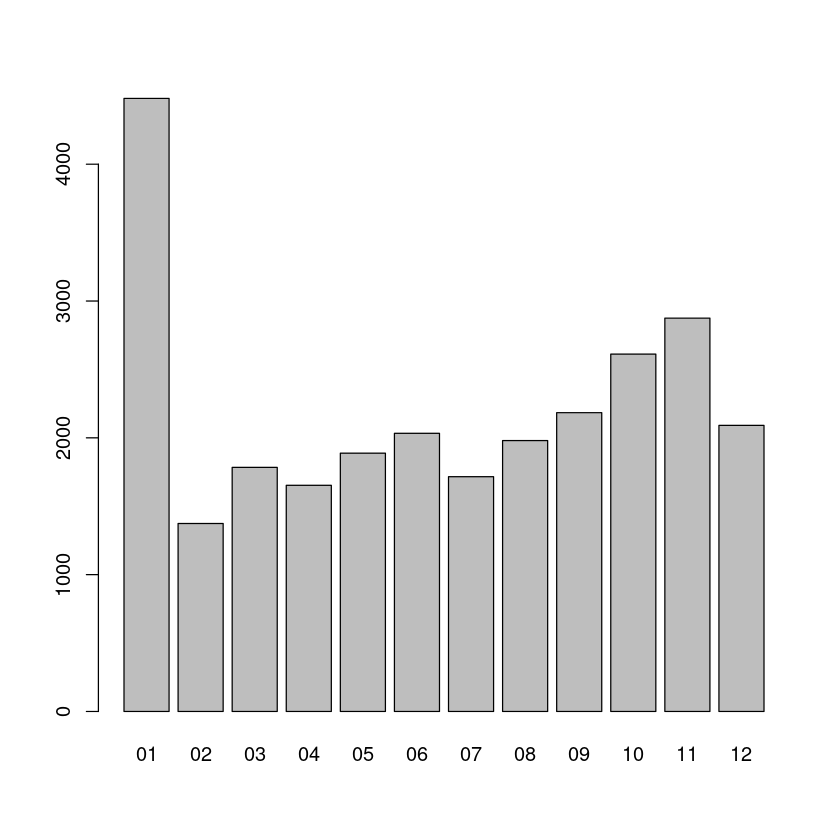

In [9]:
barplot(table(song$month))

En faisant l'histogramme des entrées en fonction du mois, on voit que le mois de janvier semble sur-représenté par rapport aux autres, on décide donc d'attribuer le mois de janvier à tous les N.A. .

In [9]:
#install.packages('moder')
library(moder)
#which(is.na(song$month), arr.ind=TRUE)
#song$month
mode <- mode_first(song$month, na.rm = TRUE)
#mode
#which(is.na(song$month))
song[which(is.na(song$month), arr.ind = TRUE),]$month = mode

In [ ]:
barplot(table(song$year))

On voit que la majorité des musique sont sorties dans les années 2010, on va donc attribuer le mode pour les données manquantes.

On va créer une variable period qui représente la décennie de sortie de la musique.

In [10]:

library(dplyr)

song <- song %>%
  mutate(
    period = case_when(
      is.na(year)              ~ "2010s",
      year > 2010              ~ "2010s",
      year > 2000              ~ "2000s",
      year > 1990              ~ "1990s",
      year > 1980              ~ "1980s",
      year > 1970              ~ "1970s",
      year > 1960              ~ "1960s",
      TRUE                     ~ "1950s"
    ))

song$month<-as.factor(song$month)
song$year<-as.factor(song$year)
song$period <- as.factor(song$period)


Attachement du package : ‘dplyr’


Les objets suivants sont masqués depuis ‘package:stats’:

    filter, lag


Les objets suivants sont masqués depuis ‘package:base’:

    intersect, setdiff, setequal, union




In [11]:
mode <- mode_first(song$year, na.rm = TRUE)
song$year[which(is.na(song$year), arr.ind = TRUE)] = mode

In [14]:
library(ggplot2)
histo_genre <- ggplot(song,aes(x=playlist_genre))+
  geom_histogram(stat="count")+
  labs(title = "Distribution des genres des musiques")

histo_year <- ggplot(song,aes(x=year))+
    geom_histogram(stat="count")+
    labs(title = "Distribution des années de sortie des musiques")+
    scale_x_discrete(breaks = levels(factor(song$year))[seq(1, length(levels(factor(song$year))), by = 10)])

histo_month <- ggplot(song,aes(x=month))+
    geom_histogram(stat="count",fill='blue')+
    labs(title = "Distribution des mois de sortie des musiques")

histo_popularity <- ggplot(song,aes(x=track_popularity))+
    geom_histogram(stat="count")+
    labs(title = "Distribution des popularités des musiques")

histo_danceability <- ggplot(song,aes(x=danceability))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la danceabilité des musiques")

histo_energy <- ggplot(song,aes(x=energy))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de l'energie des musiques")

histo_key <- ggplot(song,aes(x=key))+
    geom_histogram(bins=50,stat='count')+
    labs(title = "Distribution de la clé des musiques")

histo_loudness <- ggplot(song,aes(x=loudness))+
    geom_histogram(bins=50)+
  labs(title = "Distribution de la force sonore des musiques")

histo_mode  <- ggplot(song,aes(x=mode))+
    geom_histogram(bins=50,stat='count')+
    labs(title = "Distribution de du mode des musiques")

histo_speechiness <- ggplot(song,aes(x=speechiness))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la vocabilité des musiques")

histo_instrumentalness <- ggplot(song,aes(x=instrumentalness))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de l'intrumentabilité des musiques")

histo_liveness <- ggplot(song,aes(x=liveness))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la liveness des musiques")

histo_valence <- ggplot(song,aes(x=valence))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la valence des musiques")

histo_tempo <- ggplot(song,aes(x=tempo))+
    geom_histogram(bins=50)+
    labs(title = "Distribution du tempo des musiques")

histo_duration_s <- ggplot(song,aes(x=duration_s))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la durée des musiques")

Warning message in geom_histogram(stat = "count"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”
Warning message in geom_histogram(stat = "count"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”
Warning message in geom_histogram(stat = "count", fill = "blue"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”
Warning message in geom_histogram(stat = "count"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”
Warning message in geom_histogram(bins = 50, stat = "count"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”
Warning message in geom_histogram(bins = 50, stat = "count"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”



Attachement du package : ‘gridExtra’


L'objet suivant est masqué depuis ‘package:dplyr’:

    combine




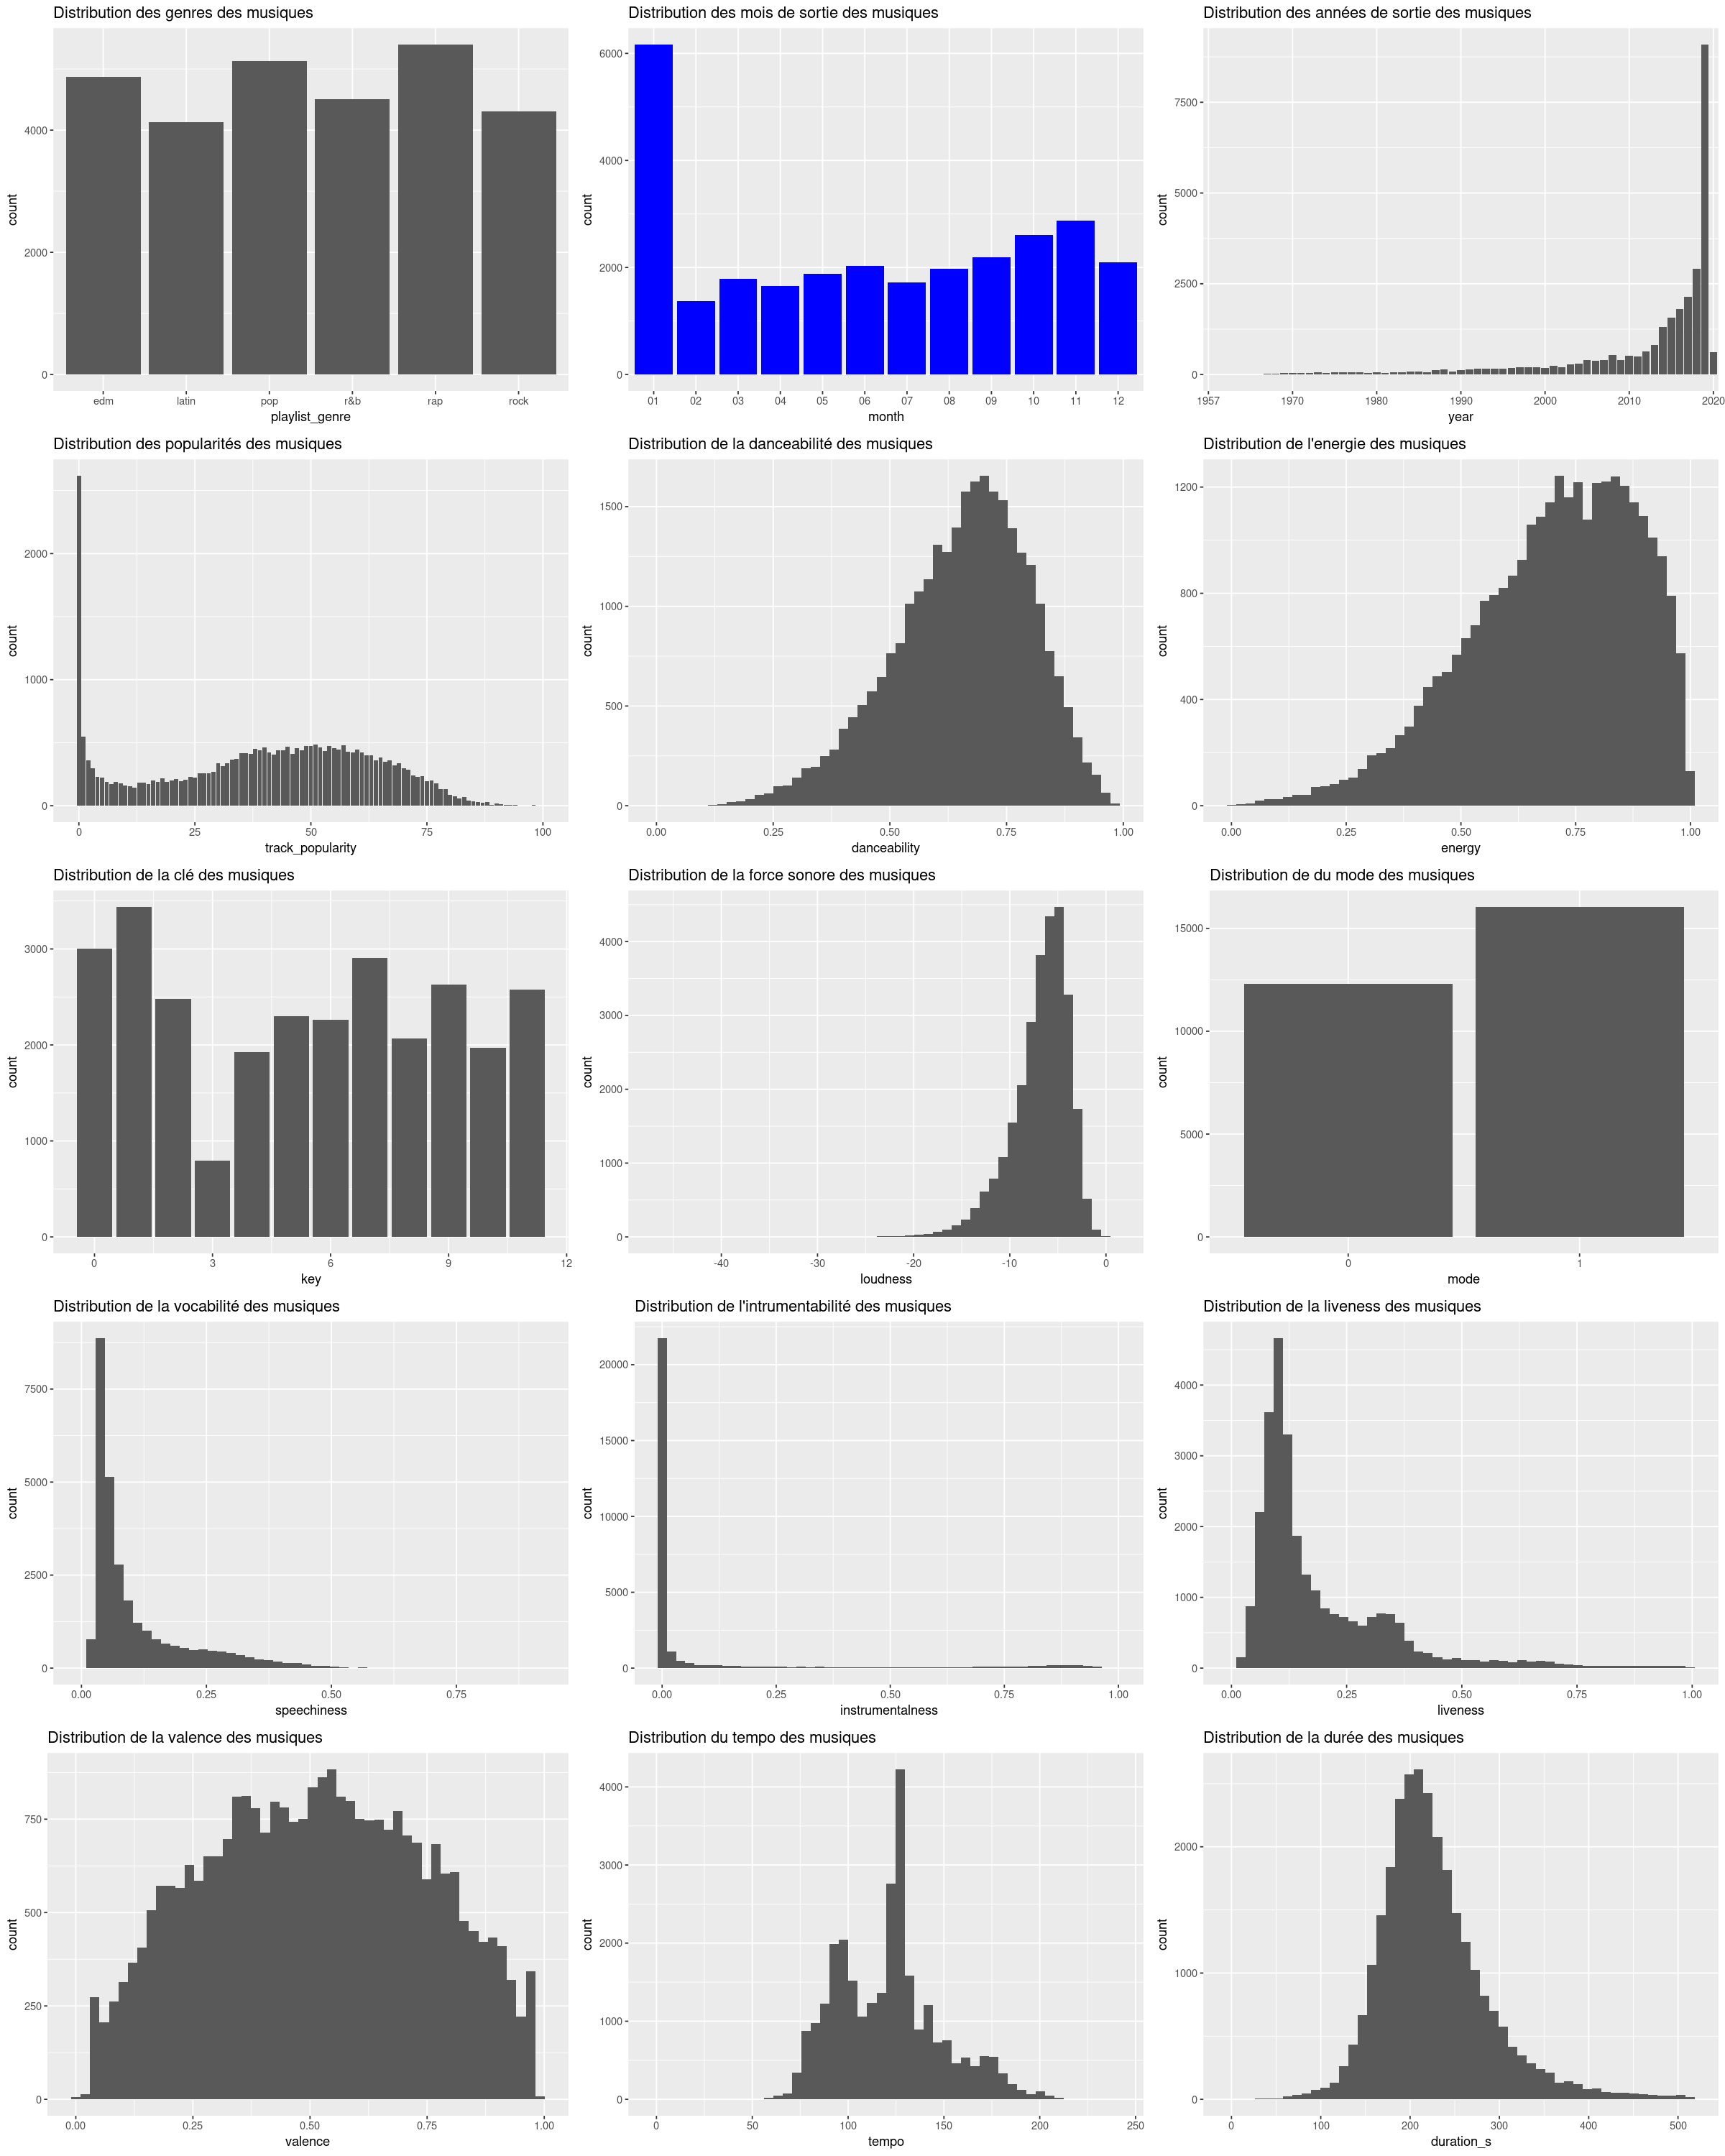

In [15]:
library("gridExtra")
options(repr.plot.width=20, repr.plot.height=25)
grid.arrange(histo_genre,histo_month,histo_year, histo_popularity,histo_danceability,histo_energy,histo_key,histo_loudness,histo_mode,histo_speechiness, histo_instrumentalness, histo_liveness,histo_valence,histo_tempo,histo_duration_s, ncol=3)

Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2

corrplot 0.92 loaded



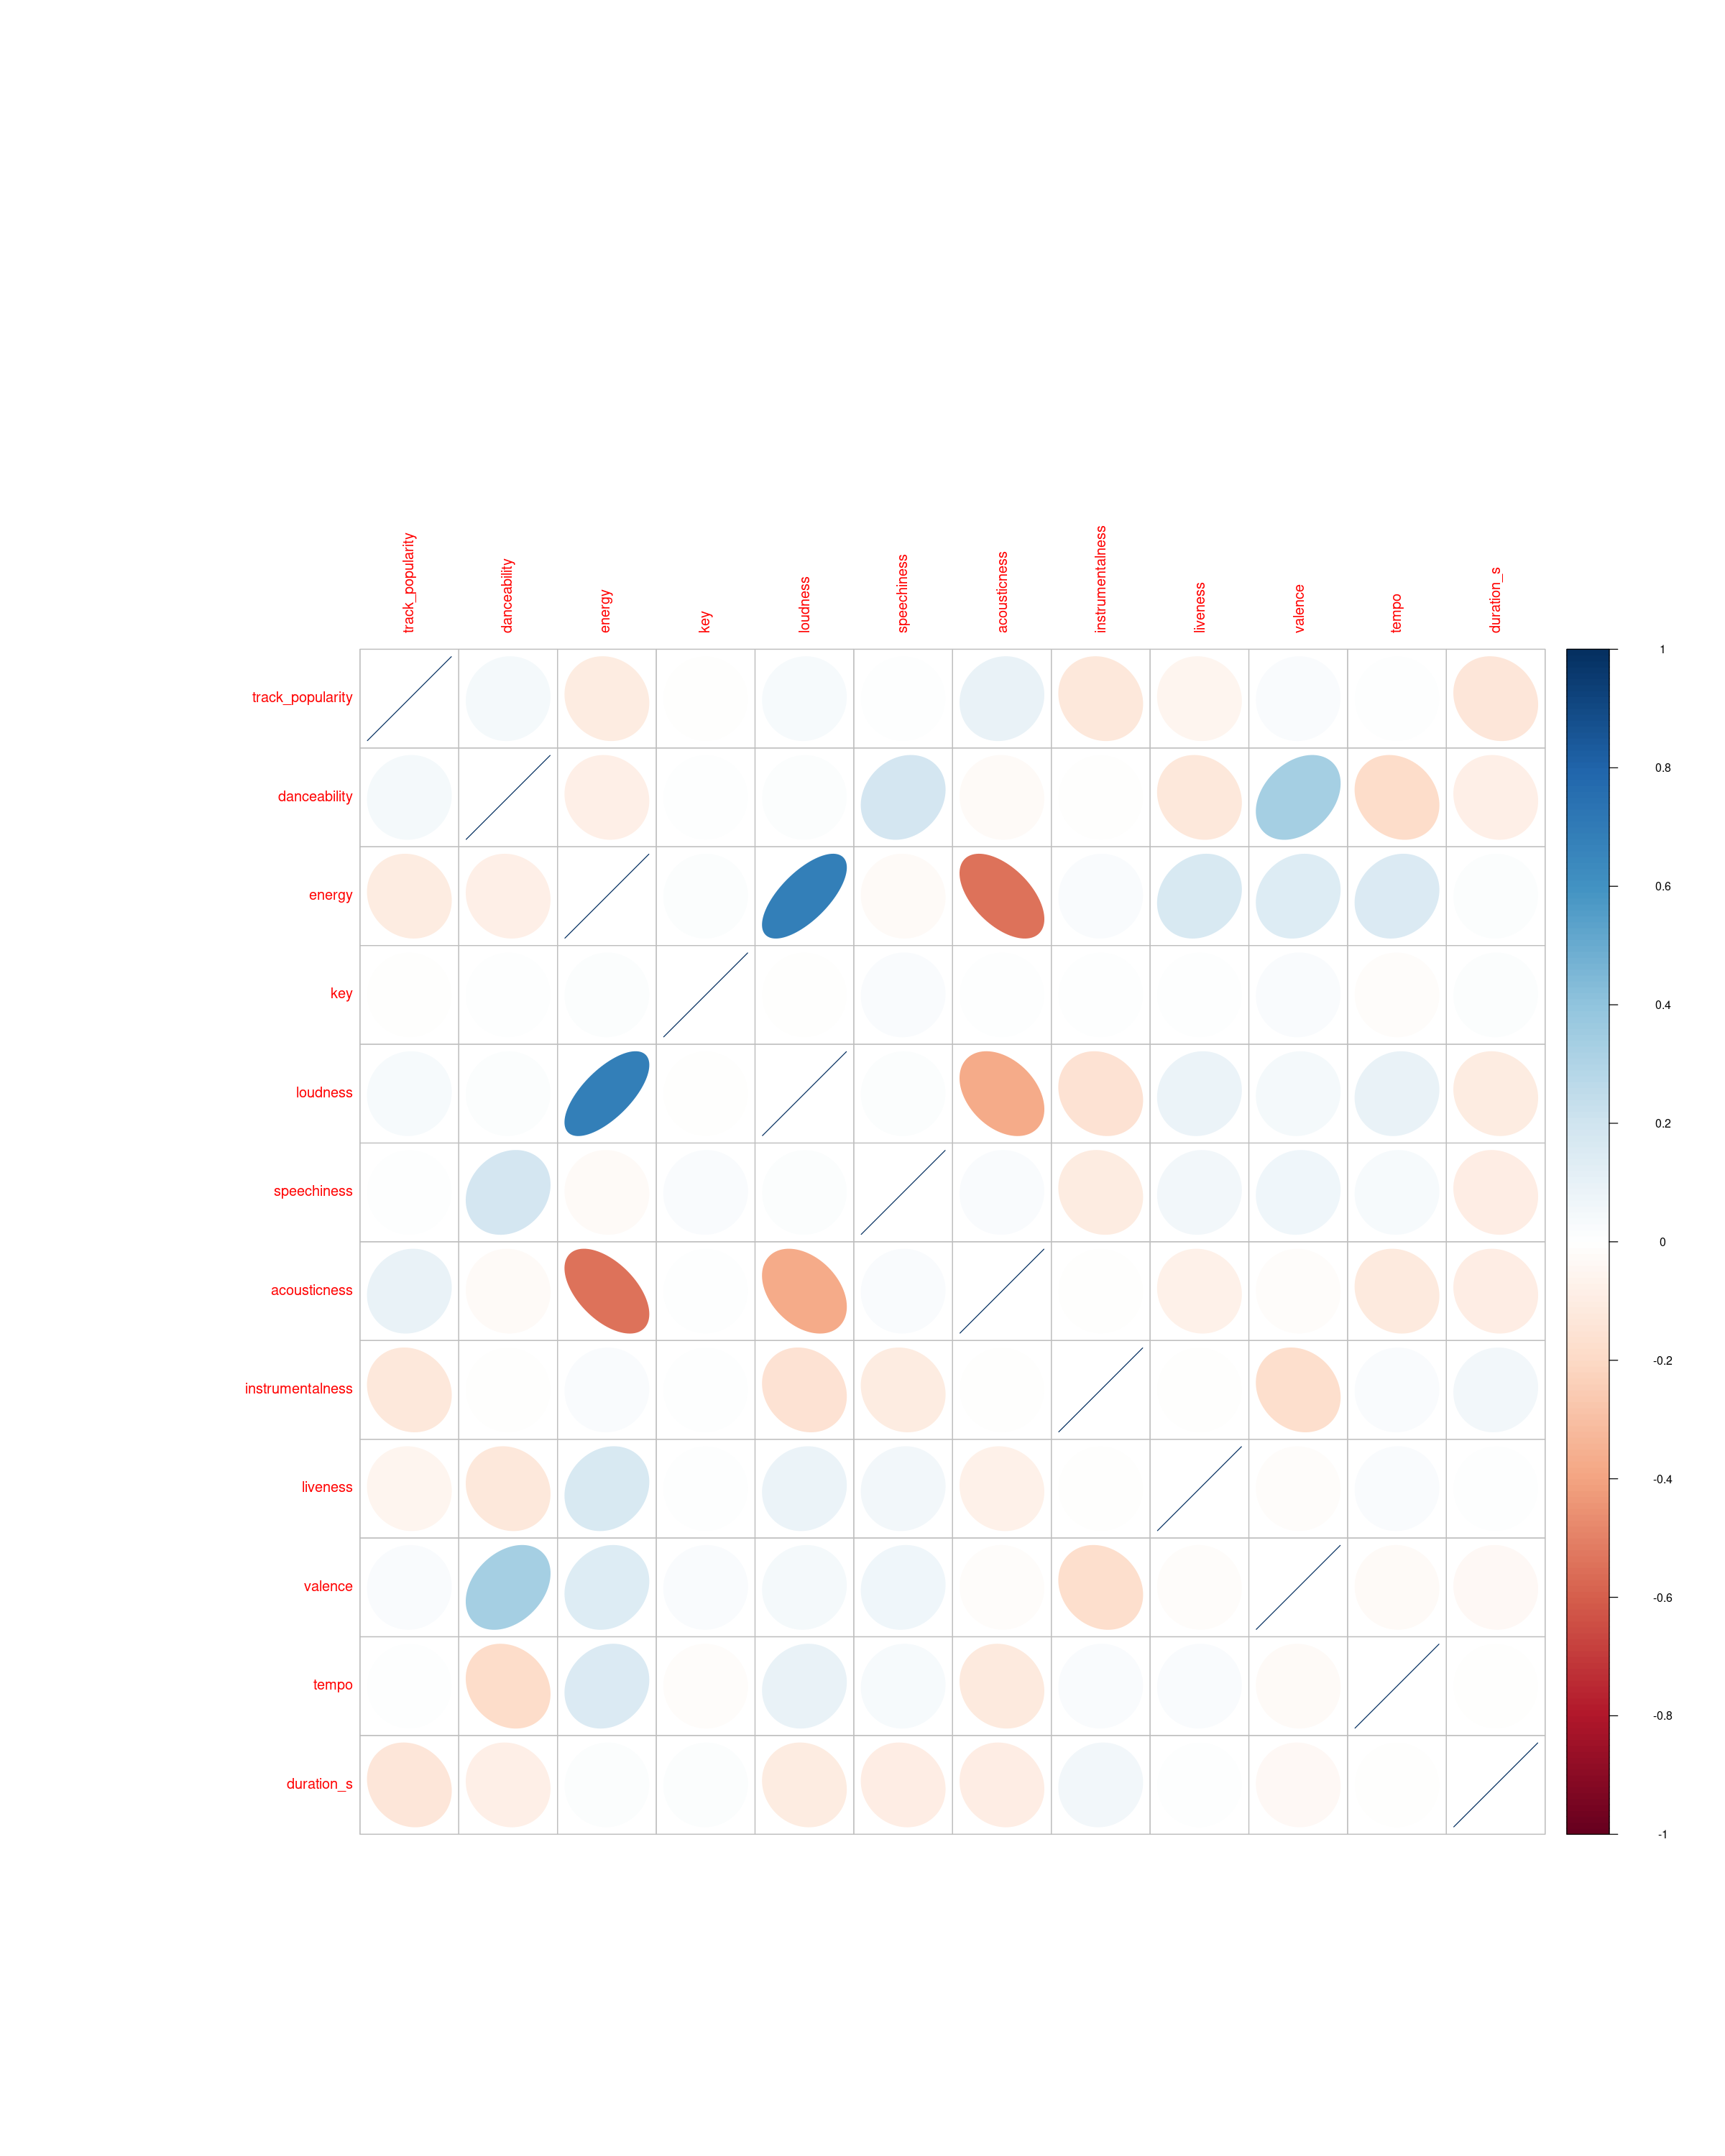

In [16]:
library(ggplot2)
library(GGally)
library(corrplot)
song_num <- song[,c(2,7:10,12:18)]
corrplot(cor(song_num), method = "ellipse")
#ggpairs(song, columns = c(2, 5, 7, 8, 9, 10, 11, 12,13,14,15,16,17,18,19), columnLabels = c("track_popularity", "playlist_genre", "danceability", "energy", "key", "loudness", "mode", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo", "duration_s", "month"))

Energy and loudness are strongly positively correlated (understandable).
Energy and acousticness are negatively correlated. Loudness and acousticness are mildly negatively correlated. It is understandable because when a song gets louder, it often becomes harder to distinguish the different instruments and sounds.
Danceability and valence are mildly positively correlated. Thus a song that is easier to dance to is one that is more likely to impulse a positive feeling to its listeners.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


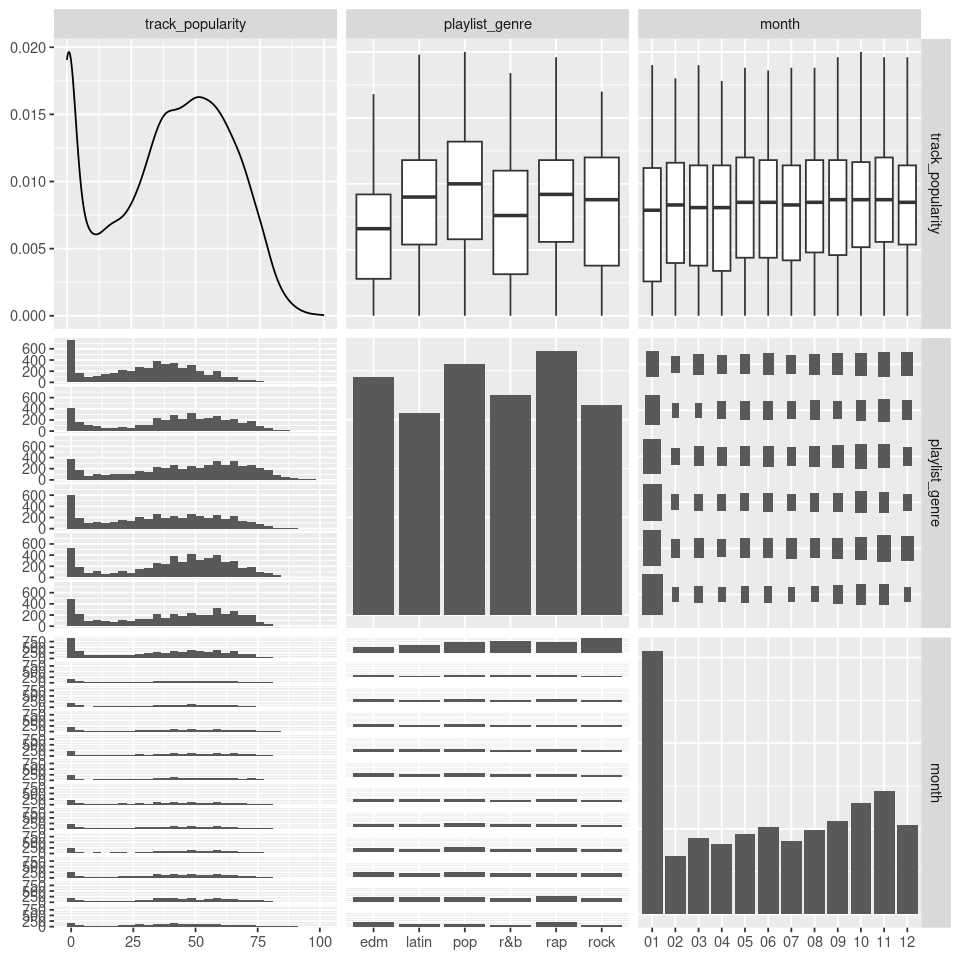

In [17]:
options(repr.plot.width=8,repr.plot.height=8)
ggpairs(song,columns=c(2, 5, 19), cardinality_threshold = 15, progress = FALSE)
#ggpairs(song,columns=c(2, 9:12), cardinality_threshold = 65, progress = FALSE)
#ggpairs(song,columns=c(2, 13:16), cardinality_threshold = 65, progress = FALSE)

We see that pop is the most popular genre in average, but the difference is slight. EDM is the least popular genre.
There does not seem to be a clear relationship between month and track popularity.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


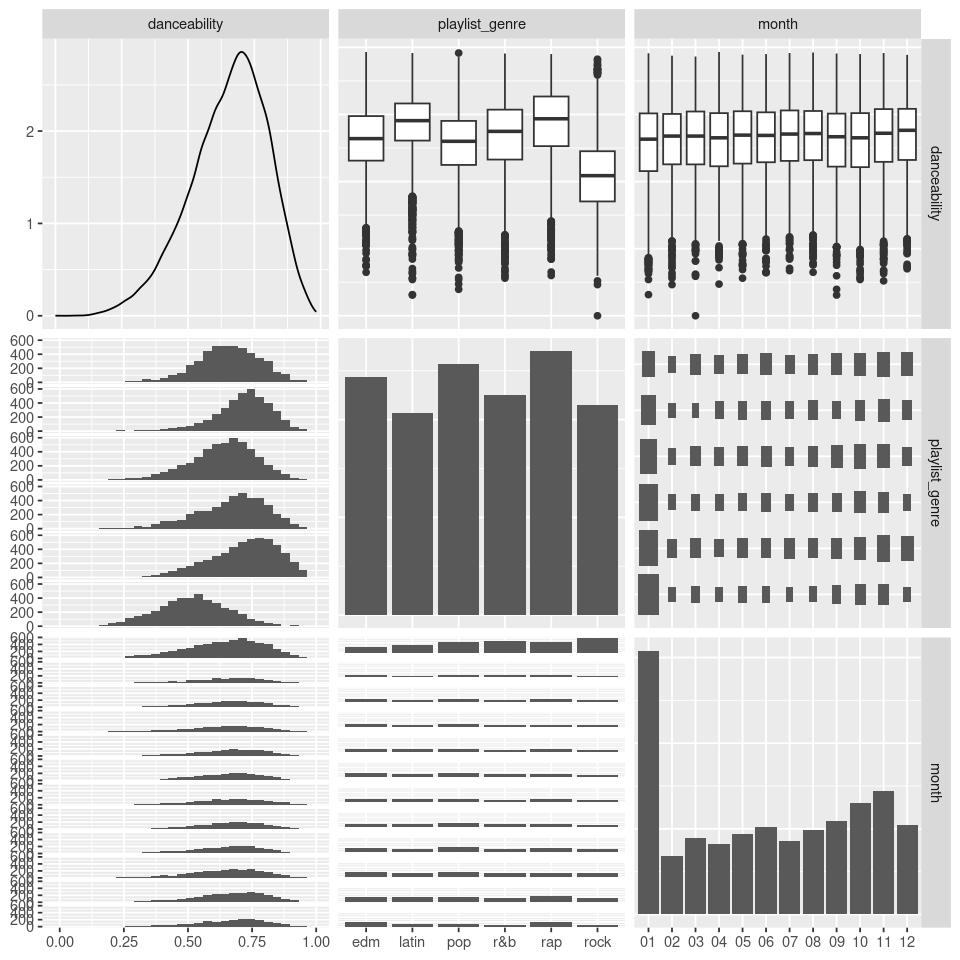

In [18]:
ggpairs(song,columns=c(7, 5, 19), cardinality_threshold = 15, progress = FALSE)

Latin and rap are the most danceable genres, rock has the worst 

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


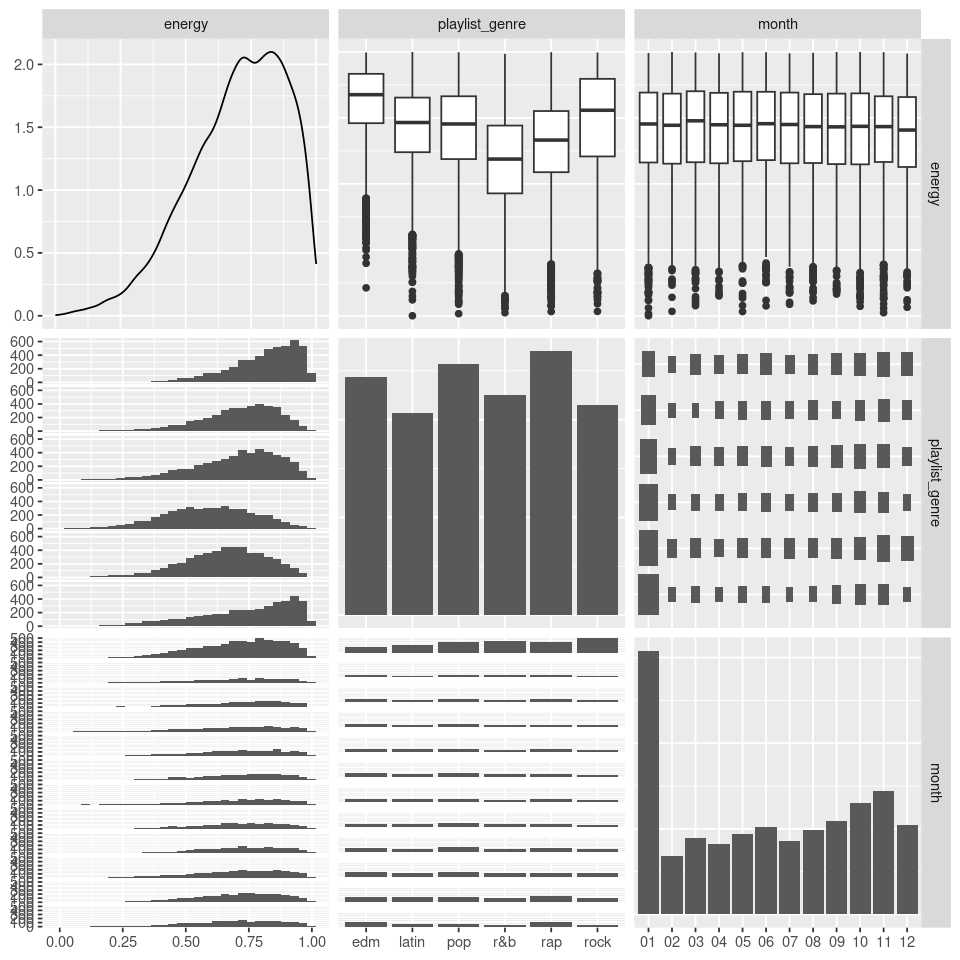

In [19]:
ggpairs(song,columns=c(8, 5, 19), cardinality_threshold = 15, progress = FALSE)

EDM is the genre with the most energy, r&b has the least energy.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


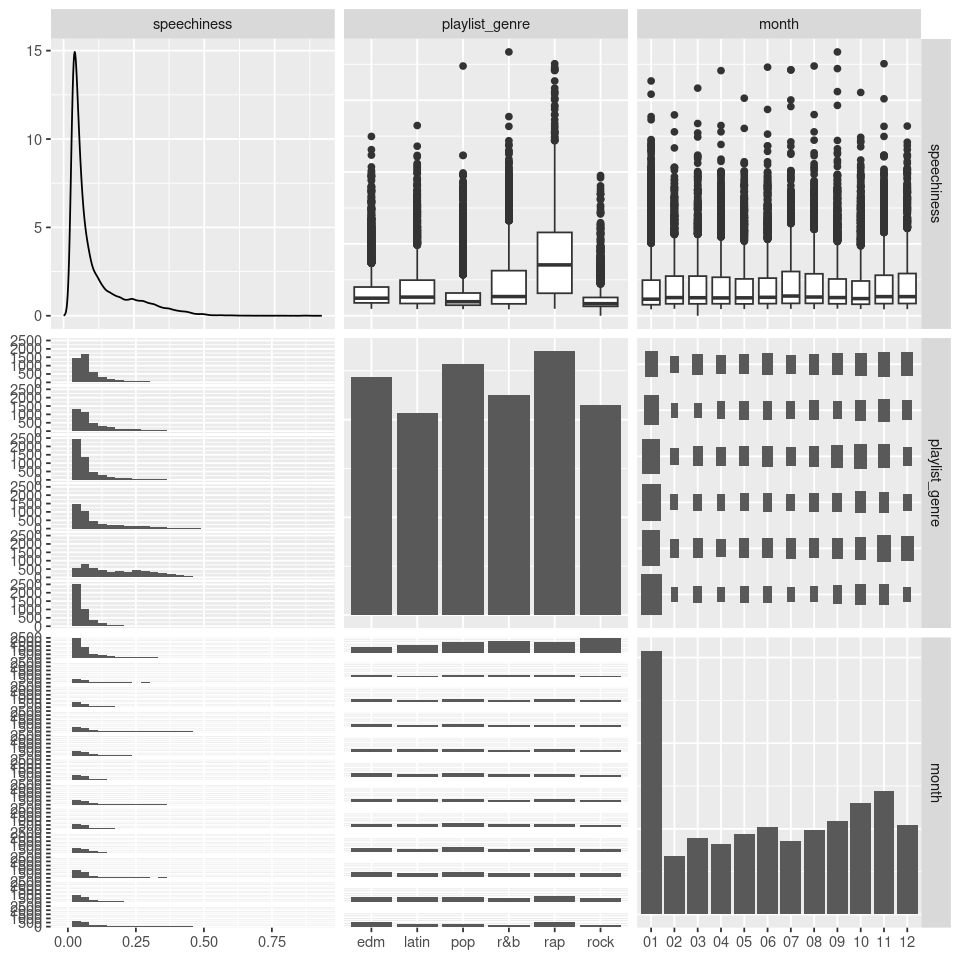

In [20]:
ggpairs(song,columns=c(12, 5, 19), cardinality_threshold = 15, progress = FALSE)

Rap has significantly more speechiness than other genres, which is understandable as it is more focused on speech.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


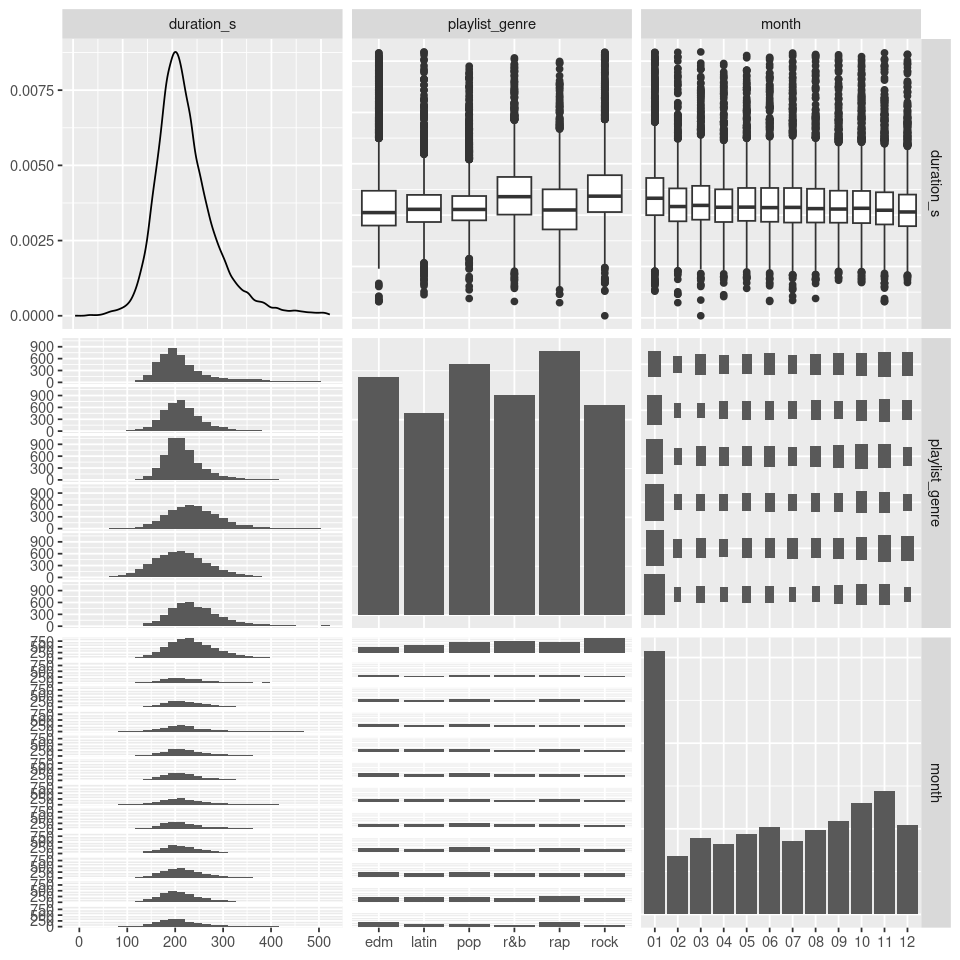

In [21]:
ggpairs(song,columns=c(18, 5, 19), cardinality_threshold = 15, progress = FALSE)

## ACP

In [12]:
library("FactoMineR")
library("factoextra")
library(reshape2)

Le chargement a nécessité le package : ggplot2

Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa


Attachement du package : ‘reshape2’


L'objet suivant est masqué depuis ‘package:tidyr’:

    smiths




In [13]:
head(song)

,track_artist,track_popularity,track_album_name,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s,month,year
,<fct>,<int>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<int>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,Ed Sheeran,66,I Don't Care (with Justin Bieber) [Loud Luxury Remix],Pop Remix,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.00e+00,0.0653,0.518,122.036,194.754,06,2019
2,Maroon 5,67,Memories (Dillon Francis Remix),Pop Remix,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,4.21e-03,0.3570,0.693,99.972,162.600,12,2019
3,Zara Larsson,70,All the Time (Don Diablo Remix),Pop Remix,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,2.33e-05,0.1100,0.613,124.008,176.616,07,2019
4,The Chainsmokers,60,Call You Mine - The Remixes,Pop Remix,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,9.43e-06,0.2040,0.277,121.956,169.093,07,2019
5,Lewis Capaldi,69,Someone You Loved (Future Humans Remix),Pop Remix,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.00e+00,0.0833,0.725,123.976,189.052,03,2019
6,Ed Sheeran,67,Beautiful People (feat. Khalid) [Jack Wins Remix],Pop Remix,pop,dance pop,0.675,0.919,8,-5.385,1,0.1270,0.0799,0.00e+00,0.1430,0.585,124.982,163.049,07,2019


In [15]:
res.pca <- PCA(song,quali.sup=c(1,3:6,11,19:20),scale.unit=TRUE,ncp=8)

Warning message in PCA(song, quali.sup = c(1, 3:6, 11, 19:20), scale.unit = TRUE, :
“Missing values are imputed by the mean of the variable: you should use the imputePCA function of the missMDA package”


On a décidé de garder la variable key dans l'ACP car même si le nombre de valeurs est fini, elles sont ordonnées. Key représente la tonalité de la musique, augmenter de 1 la key augmente le ton de 0.5 .

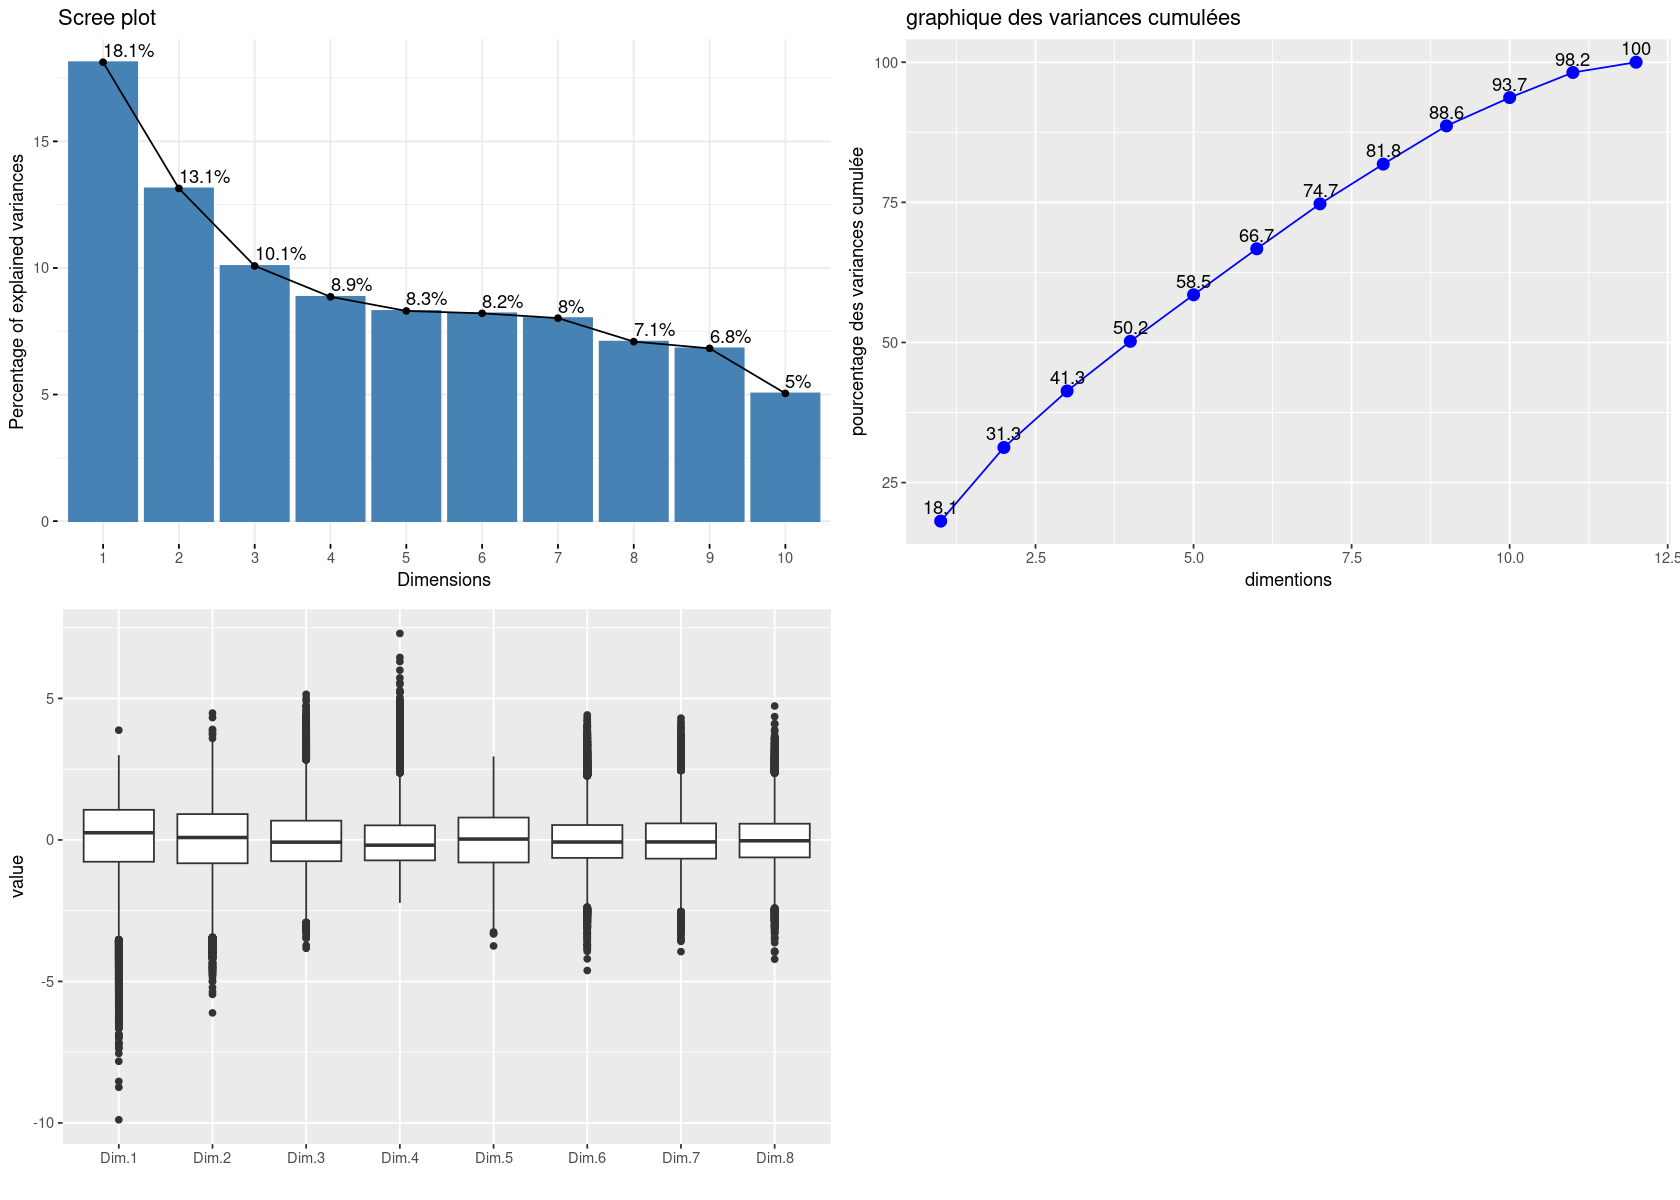

In [24]:
options(repr.plot.width=14,repr.plot.height=10)
#décroissance valeurs propres
g1<-fviz_eig(res.pca,addlabels=TRUE)

#variances cumulées
cum_var <- cumsum(res.pca$eig[,2])

# Graphique avec ggplot2
g2<-ggplot(data.frame(Dimension = 1:length(cum_var), Variance = cum_var), aes(x = Dimension, y = Variance)) +
    geom_point(size = 3, color = "blue") +
    geom_line(color = "blue") +
    labs(title = "graphique des variances cumulées",x='dimentions', y = "pourcentage des variances cumulée") +
    geom_text(aes(y = cum_var, label = round(cum_var, 1)), vjust = -0.5, color = "black") 

g3<-ggplot(melt(res.pca$ind$coord),aes(x=Var2,y=value))+
  geom_boxplot()+
  xlab("")
grid.arrange(g1,g2,g3,ncol=2)

Pour atteindre 80% de la variance, on a besoin de garder 8 composantes. Ce n'est pas très performant, la dimension n'est pas vraiment réduite.

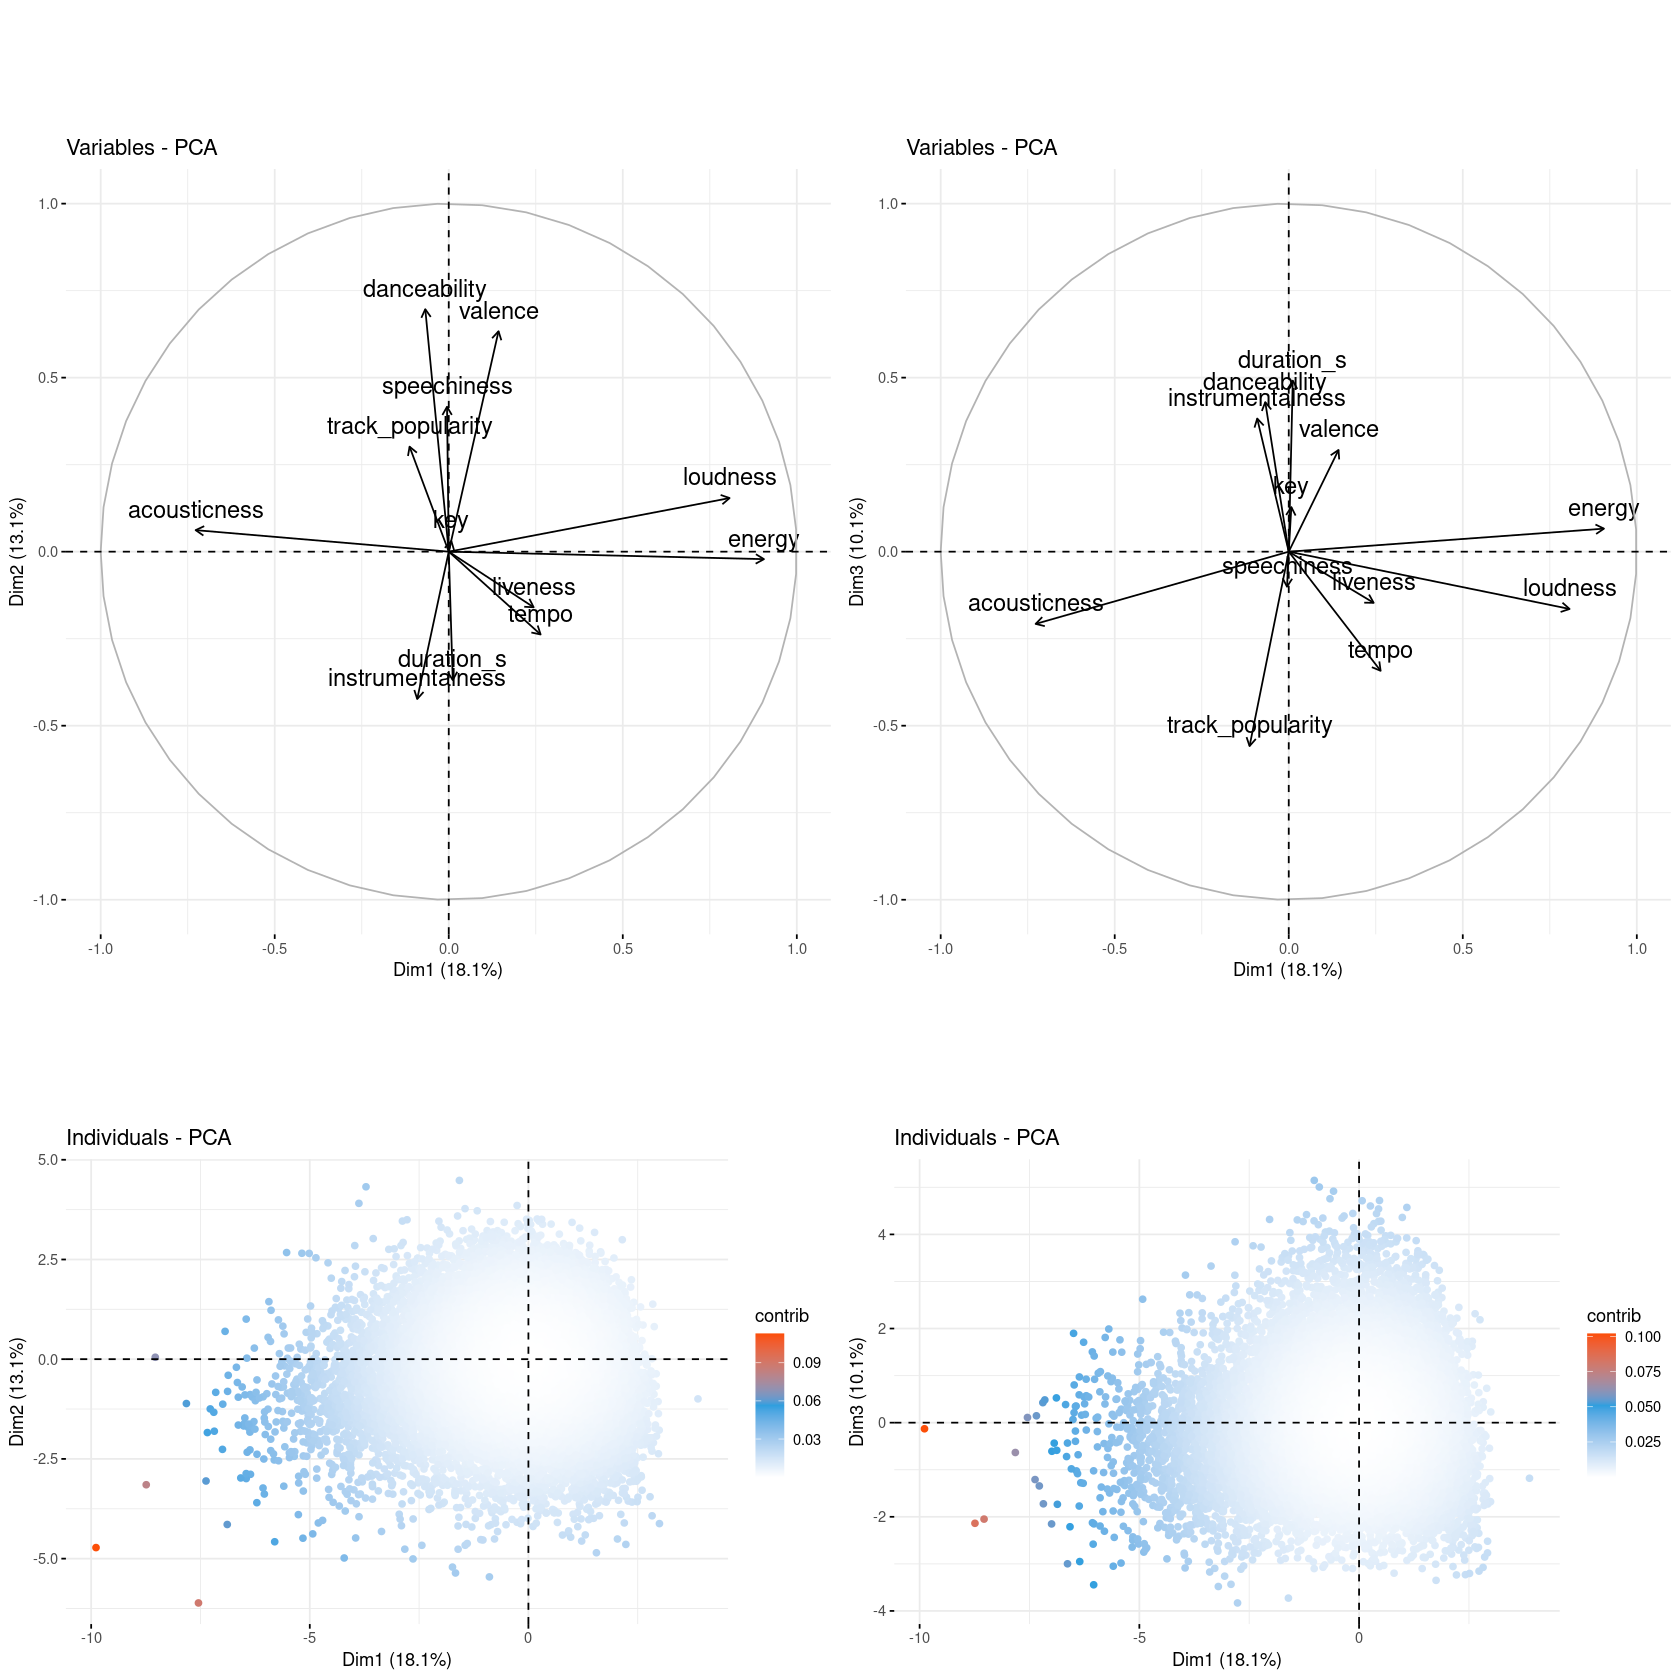

In [25]:
options(repr.plot.width=14,repr.plot.height=14)
g4<-fviz_pca_var(res.pca,labelsize = 5)
g5<-fviz_pca_ind(res.pca, col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ))
g6<-fviz_pca_var(res.pca,axes=c(1,3),labelsize = 5)
g7<-fviz_pca_ind(res.pca,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ),axes=c(1,3))

grid.arrange(g4,g6,g5,g7,ncol=2,nrow=2,heights=c(2,1))

In [26]:
contrib_ind<-res.pca$ind$contrib[,c(1,2)]
top_ind<-order(contrib_ind,decreasing=TRUE)[1:3]
song[top_ind,]

,track_artist,track_popularity,track_album_name,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,⋯,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s,month,year,period
,<fct>,<int>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<int>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>
15578,The Sleep Specialist,51,Jungle And Forest Sounds,Tropical Nights,latin,tropical,0.211,0.4250,7,-46.448,⋯,0.0542,0.880,6.13e-01,0.184,0.0122,116.884,181.204,01,2017,2010s
21429,Chico DeBarge,0,Long Time No See,90s R&B - The BET Planet Groove/Midnight Love Mix,r&b,new jack swing,0.220,0.0286,1,-34.283,⋯,0.0562,0.943,0.00e+00,0.218,0.0383,128.899,31.893,11,1997,1990s
15585,Nature Sounds,50,"Nature Sounds with Birdsong, Waves, Forest, Garden, And More Beautiful Sounds of the Earth!",Tropical Nights,latin,tropical,0.318,0.1790,8,-35.427,⋯,0.4790,0.877,3.82e-05,0.226,0.4220,97.368,45.000,04,2015,2010s


Les 3 individus qui contribuent plus que les autres dans les deux premiers plans factoriels ne sont peut-être pas des outliers mais des musiques qui sont très bien expliquées par ses plans factoriels car ce sont des musiques très spécifiques/particulières.

La première dimension sépare les musiques plutôt dynamique/énergique et les musiques plus fluides/calmes.
La seconde dimension sépare les musiques populaires/dansantes/courtes et la musique plus classique/instrumentale/longue.
La troisième dimension sépare les musiques populaires et les musiques dansantes type bal.
La quatrième dimension représente les musiques enregistrées en concert.
La cinquième dimension représente la clé de la musique.
Les 3 dernières dimensions sont difficilement interprétables.

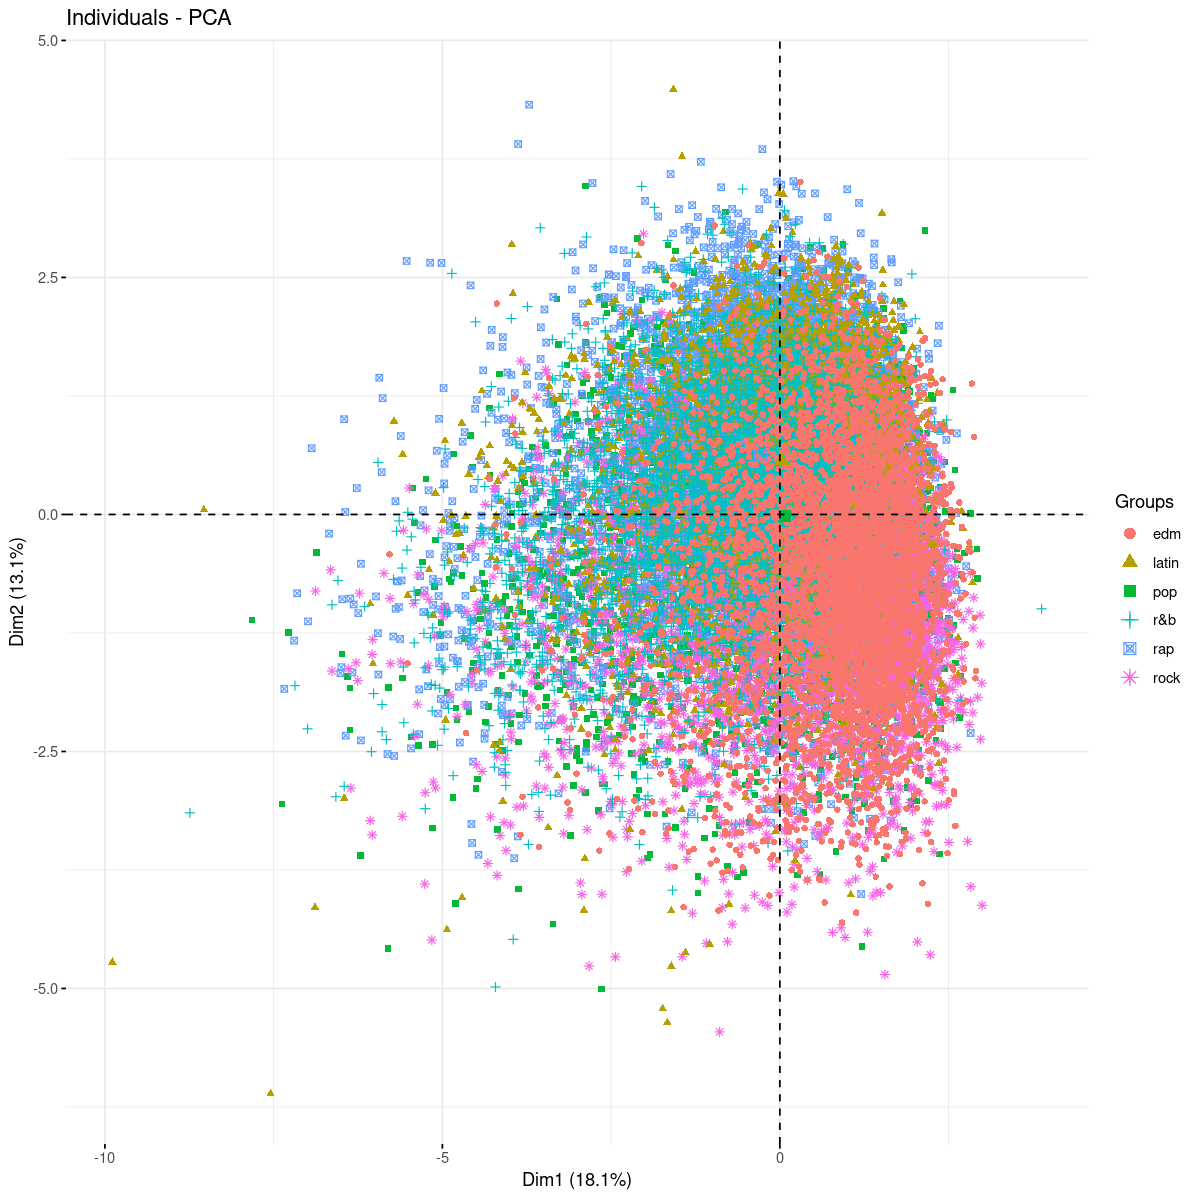

In [27]:
options(repr.plot.width=10,repr.plot.height=10)
g8<-fviz_pca_ind(res.pca, habillage=song$playlist_genre,label="none")
g8

On voit qu'on ne peut pas discriminer le genre de musique avec uniquement le premier plan factoriel.

## LDA,QDA,KNN pour prédire le genre

## LDA

On va faire une LDA pour essayer de prédire le genre de la playlist dans laquelle se trouve la musique.

Pour facilliter la LDA, on va transformer les variables qualitatives en one-hot. On ne va pas garder que les propriétés physiques de la musique + la popularité. On va supprimer aussi le sous genre car si on ne connait pas le genre on ne connait pas le sous genre.
On va scale les données quantitatives comme pour l'ACP afin que les variables tempo et duration_s ne prennent pas trop d'importance par rapport aux autres variables qui ne prennent pas les mêmes échelles de valeurs.

In [13]:
songLDA<-subset(song, select=-track_artist)
songLDA<-subset(songLDA, select=-track_album_name)
songLDA<-subset(songLDA, select=-playlist_name)
songLDA<-subset(songLDA, select=-playlist_subgenre)
songLDA<-subset(songLDA, select=-month)
songLDA<-subset(songLDA, select=-year)
songLDA<-subset(songLDA, select=-period)
#songLDA<-subset(songLDA, select=-pop)

In [29]:
songLDA[,c(1,3:4,6,8:14)]<-scale(songLDA[,c(1,3:4,6,8:14)])
head(songLDA)

,track_popularity,playlist_genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s
,<dbl>,<fct>,<dbl>,<dbl>,<int>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1.1251184,pop,0.6490454,1.1859272,6,1.3778591,1,-0.48406214,-0.3374649,-0.3918495,-0.80605901,0.03249277,0.03998519,-0.5209548
2,1.1673135,pop,0.4981442,0.6355434,11,0.6088647,1,-0.68884578,-0.4703109,-0.3737468,1.06515899,0.77925866,-0.77857938,-1.0473674
3,1.2938987,pop,0.1483278,1.2676674,1,1.1150507,0,-0.32901166,-0.4388947,-0.3917493,-0.51931426,0.43787997,0.11314551,-0.8179030
4,0.8719479,pop,0.4432710,1.2622181,7,1.0011012,1,-0.05791713,-0.6664383,-0.3918089,0.08368366,-0.99591055,0.03701722,-0.9410666
5,1.2517037,pop,-0.0231509,0.7336316,1,0.7066768,1,-0.70249802,-0.4348554,-0.3918495,-0.69059133,0.91581014,0.11195832,-0.6143057
6,1.1673135,pop,0.1483278,1.2022753,8,0.4718618,1,0.18587292,-0.4366506,-0.3918495,-0.30762350,0.31839742,0.14928047,-1.0400166


In [30]:
#install.packages('MASS')
#install.packages("effectsize")

In [31]:
library(MASS)
library(effectsize)
set.seed(42)
sample<-sample(c(TRUE,FALSE),nrow(songLDA),replace=TRUE,prob=c(0.7,0.3))
songLDA<-standardize(songLDA,exclude=c("playlist_genre","mode"))
train<-songLDA[sample,]
test<-songLDA[!sample,]


res.lda<-lda(playlist_genre~.,data=train)


Attachement du package : ‘MASS’


L'objet suivant est masqué depuis ‘package:dplyr’:

    select




In [32]:
lda_pred<-predict(res.lda,test)

In [33]:
library(caret)
conf_matrix <- confusionMatrix(lda_pred$class, factor(test$playlist_genre))
print(conf_matrix)

Le chargement a nécessité le package : lattice



Confusion Matrix and Statistics

          Reference
Prediction edm latin pop r&b rap rock
     edm   825   151 171  55 143  106
     latin 110   365 205 172 170   83
     pop   264   260 605 188 167  170
     r&b    66   140 185 497 151  139
     rap   130   218 144 265 901   20
     rock   72    86 277 149  68  775

Overall Statistics
                                          
               Accuracy : 0.4672          
                 95% CI : (0.4566, 0.4779)
    No Information Rate : 0.1884          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.3588          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       

Statistics by Class:

                     Class: edm Class: latin Class: pop Class: r&b Class: rap
Sensitivity             0.56237      0.29918    0.38122    0.37481     0.5631
Specificity             0.91090      0.89825    0.84810    0.90498     0.8873
Pos Pred Value   

On obtient une précision de 47% sur la classification ce qui n'est pas très bon.

Essayer QDA, LDA sur espace d'ACP

## LDA sur Espace d'ACP

In [34]:
trainACP<-res.pca$ind$coord[sample,]
trainACP = as.data.frame(trainACP)
trainACP$playlist_genre = train$playlist_genre
testACP<-res.pca$ind$coord[!sample,]
testACP = as.data.frame(testACP)
res.lda<-lda(playlist_genre~.,data=trainACP)

In [35]:
lda_pred<-predict(res.lda,testACP)

In [36]:
conf_matrix <- confusionMatrix(lda_pred$class, factor(test$playlist_genre))
print(conf_matrix)

Confusion Matrix and Statistics

          Reference
Prediction edm latin pop r&b rap rock
     edm   774   117 188  52 124  167
     latin  89   339 204 178 164   98
     pop   282   288 649 181 214  264
     r&b    53   140 176 477 157  171
     rap   140   244 158 287 883   20
     rock  129    92 212 151  58  573

Overall Statistics
                                          
               Accuracy : 0.4351          
                 95% CI : (0.4245, 0.4457)
    No Information Rate : 0.1884          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.3192          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       

Statistics by Class:

                     Class: edm Class: latin Class: pop Class: r&b Class: rap
Sensitivity             0.52761      0.27787    0.40895    0.35973     0.5519
Specificity             0.90777      0.89922    0.82204    0.90275     0.8768
Pos Pred Value   

Pas fou

## QDA

In [37]:
res.qda<-qda(playlist_genre~.,data=train)

In [38]:
qda_pred<-predict(res.qda,test)

In [39]:
conf_matrix <- confusionMatrix(qda_pred$class, factor(test$playlist_genre))
print(conf_matrix)

Confusion Matrix and Statistics

          Reference
Prediction edm latin pop r&b rap rock
     edm   970   153 213  63  92   97
     latin  60   307 101 123 145   31
     pop   207   309 696 193 227  174
     r&b    58   187 200 589 257  129
     rap    97   163 116 186 822   36
     rock   75   101 261 172  57  826

Overall Statistics
                                         
               Accuracy : 0.4957         
                 95% CI : (0.485, 0.5064)
    No Information Rate : 0.1884         
    P-Value [Acc > NIR] : < 2.2e-16      
                                         
                  Kappa : 0.3929         
                                         
 Mcnemar's Test P-Value : < 2.2e-16      

Statistics by Class:

                     Class: edm Class: latin Class: pop Class: r&b Class: rap
Sensitivity              0.6612      0.25164    0.43856    0.44419    0.51375
Specificity              0.9120      0.93675    0.83927    0.88405    0.91325
Pos Pred Value           0

> On remarque que l'on atteint environ 50% de précision, ce qui est visiblement meilleur que la LDA/LDA dans l'espace d'ACP. Cependant, il serait souhaitable d'avoir de meilleurs résultats.

## kNN

In [40]:
knn_genre<-train(playlist_genre~.,data=train,method="knn",trControl=trainControl(method="cv"),tuneGrid=data.frame(k=seq(5,25)))

In [41]:
knn_genre

k-Nearest Neighbors 

19859 samples
   13 predictor
    6 classes: 'edm', 'latin', 'pop', 'r&b', 'rap', 'rock' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 17876, 17871, 17874, 17874, 17873, 17873, ... 
Resampling results across tuning parameters:

  k   Accuracy   Kappa    
   5  0.4685002  0.3612014
   6  0.4699598  0.3628298
   7  0.4804362  0.3753688
   8  0.4847666  0.3804904
   9  0.4887449  0.3852646
  10  0.4908596  0.3877116
  11  0.4951367  0.3929057
  12  0.4974035  0.3955918
  13  0.5026415  0.4018239
  14  0.5001743  0.3988268
  15  0.5036982  0.4030804
  16  0.5046558  0.4041995
  17  0.5069223  0.4069109
  18  0.5093883  0.4099127
  19  0.5086835  0.4090283
  20  0.5119052  0.4128847
  21  0.5123586  0.4133982
  22  0.5112515  0.4120836
  23  0.5126611  0.4137402
  24  0.5122588  0.4132734
  25  0.5138687  0.4151721

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was k = 25.

In [42]:
best_knn<-knn3(playlist_genre~.,data=train,k=knn_genre$bestTune$k)
pred_genre<-predict(best_knn,test,type="class")
conf_matrix <- confusionMatrix(pred_genre, factor(test$playlist_genre))
print(conf_matrix)

Confusion Matrix and Statistics

          Reference
Prediction  edm latin  pop  r&b  rap rock
     edm   1010   144  222   67  124  110
     latin   84   462  211  163  162   67
     pop    184   202  622  204  136  187
     r&b     51   154  192  532  174  137
     rap     86   186  122  256  954   25
     rock    52    72  218  104   50  767

Overall Statistics
                                          
               Accuracy : 0.5118          
                 95% CI : (0.5011, 0.5225)
    No Information Rate : 0.1884          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.4126          
                                          
 Mcnemar's Test P-Value : 1.64e-11        

Statistics by Class:

                     Class: edm Class: latin Class: pop Class: r&b Class: rap
Sensitivity              0.6885       0.3787    0.39193    0.40121     0.5962
Specificity              0.9051       0.9055    0.86780    0.90121 

A nouveau environ 51% de précision ce qui n'est toujours pas satisfaisant.

## CA

#### Nous transformons la variable quantitative `track_popularity` en variable qualitative, afin de l'utiliser dans une CA sur elle et la variable `playlist_genre `. Pour vérifier l'indépendance,on utilise un test du $\chi^2$.

In [43]:
library(gplots)
library(graphics)
library(ggpubr)


Attachement du package : ‘gplots’


L'objet suivant est masqué depuis ‘package:stats’:

    lowess




In [44]:
song$track_popularity_quali <- as.factor(floor((song$track_popularity)/10))

In [45]:
table_genre_popu<-table(song$playlist_genre,song$track_popularity_quali)

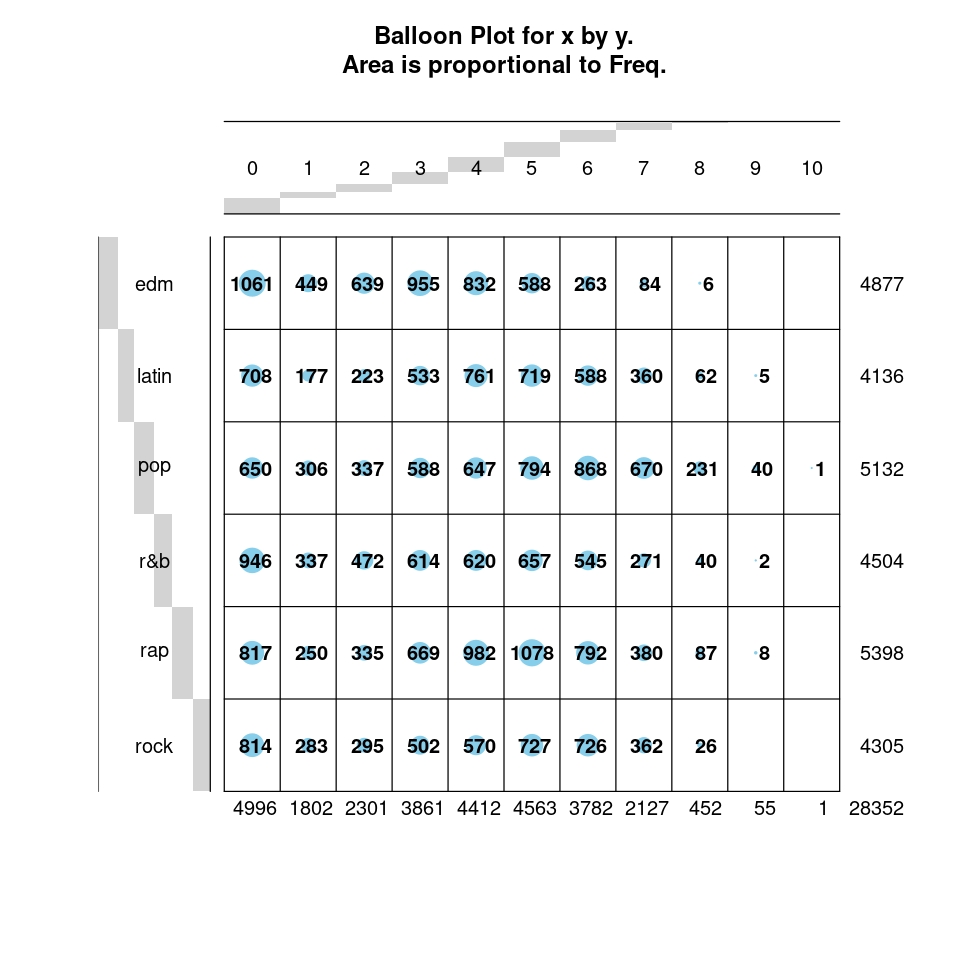

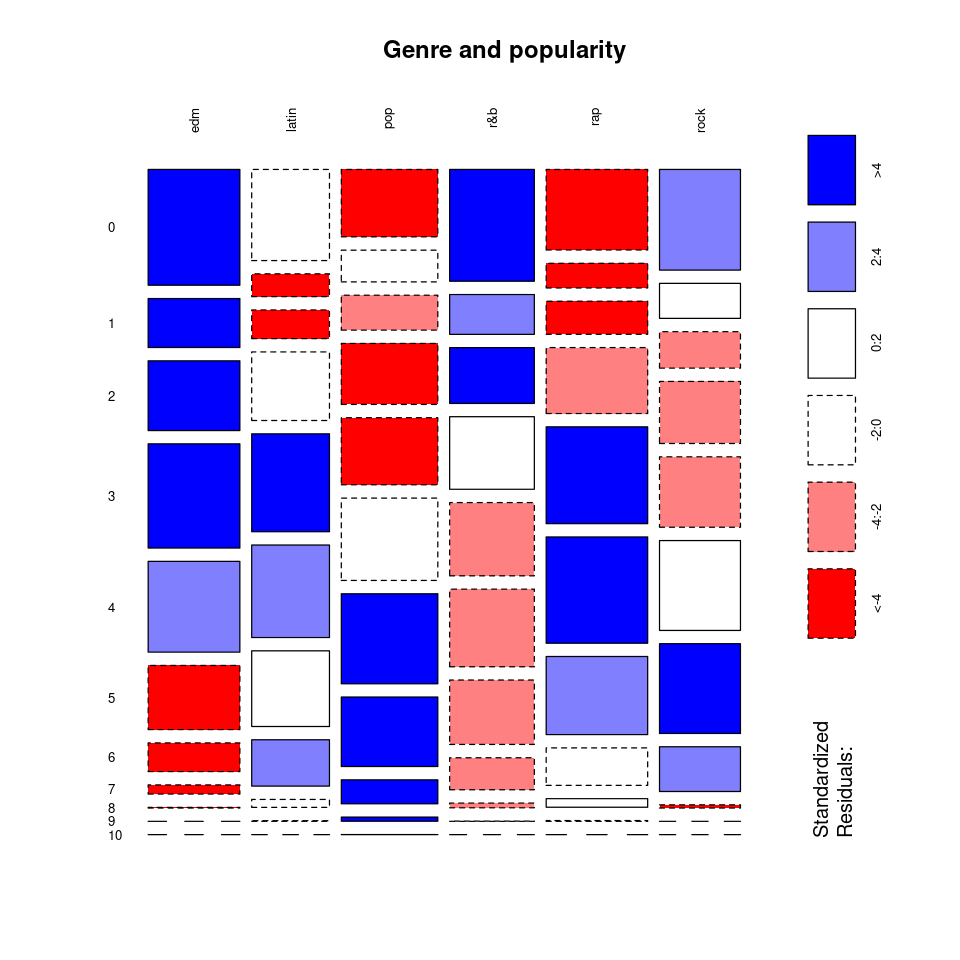

In [46]:
options(repr.plot.width=8,repr.plot.height=8)
balloonplot(t(table_genre_popu))
mosaicplot(table_genre_popu, shade = TRUE, las=2, main = "Genre and popularity")

> On observe qu'il y a très peu de sons populaires et les dépendances entres facteurs ne sont pas flagrantes. Nous allons mainteneant réalisé un test du $\chi^2$ pour voir si il y a indépendance et si la CA est utile ou non.

In [47]:
chisq.test(table_genre_popu)

Warning message in chisq.test(table_genre_popu):
“L’approximation du Chi-2 est peut-être incorrecte”



	Pearson's Chi-squared test

data:  table_genre_popu
X-squared = 2236.9, df = 50, p-value < 2.2e-16


> La p-valeur est inférieur au niveau de confiance 5%, on rejette donc l'hypothèse d'indépendance à se niveau de confiance. On va donc pouvoir faire une CA pour trouver ces dépendances.

In [48]:
res.ca = CA(table_genre_popu, graph=FALSE)

In [49]:
res.ca$eig

,eigenvalue,percentage of variance,cumulative percentage of variance
dim 1,0.0587340033,74.4436803,74.44368
dim 2,0.0130649003,16.5593898,91.00307
dim 3,0.0058704757,7.4406612,98.44373
dim 4,0.0009040333,1.1458365,99.58957
dim 5,0.0003238196,0.4104322,100.00000


> On voit qu'avec 2 dimensions on conserve plus de 90% de la variance ce qui est très satisfaisant. On va maintenant plot les facteurs dans le premier plan de CA.

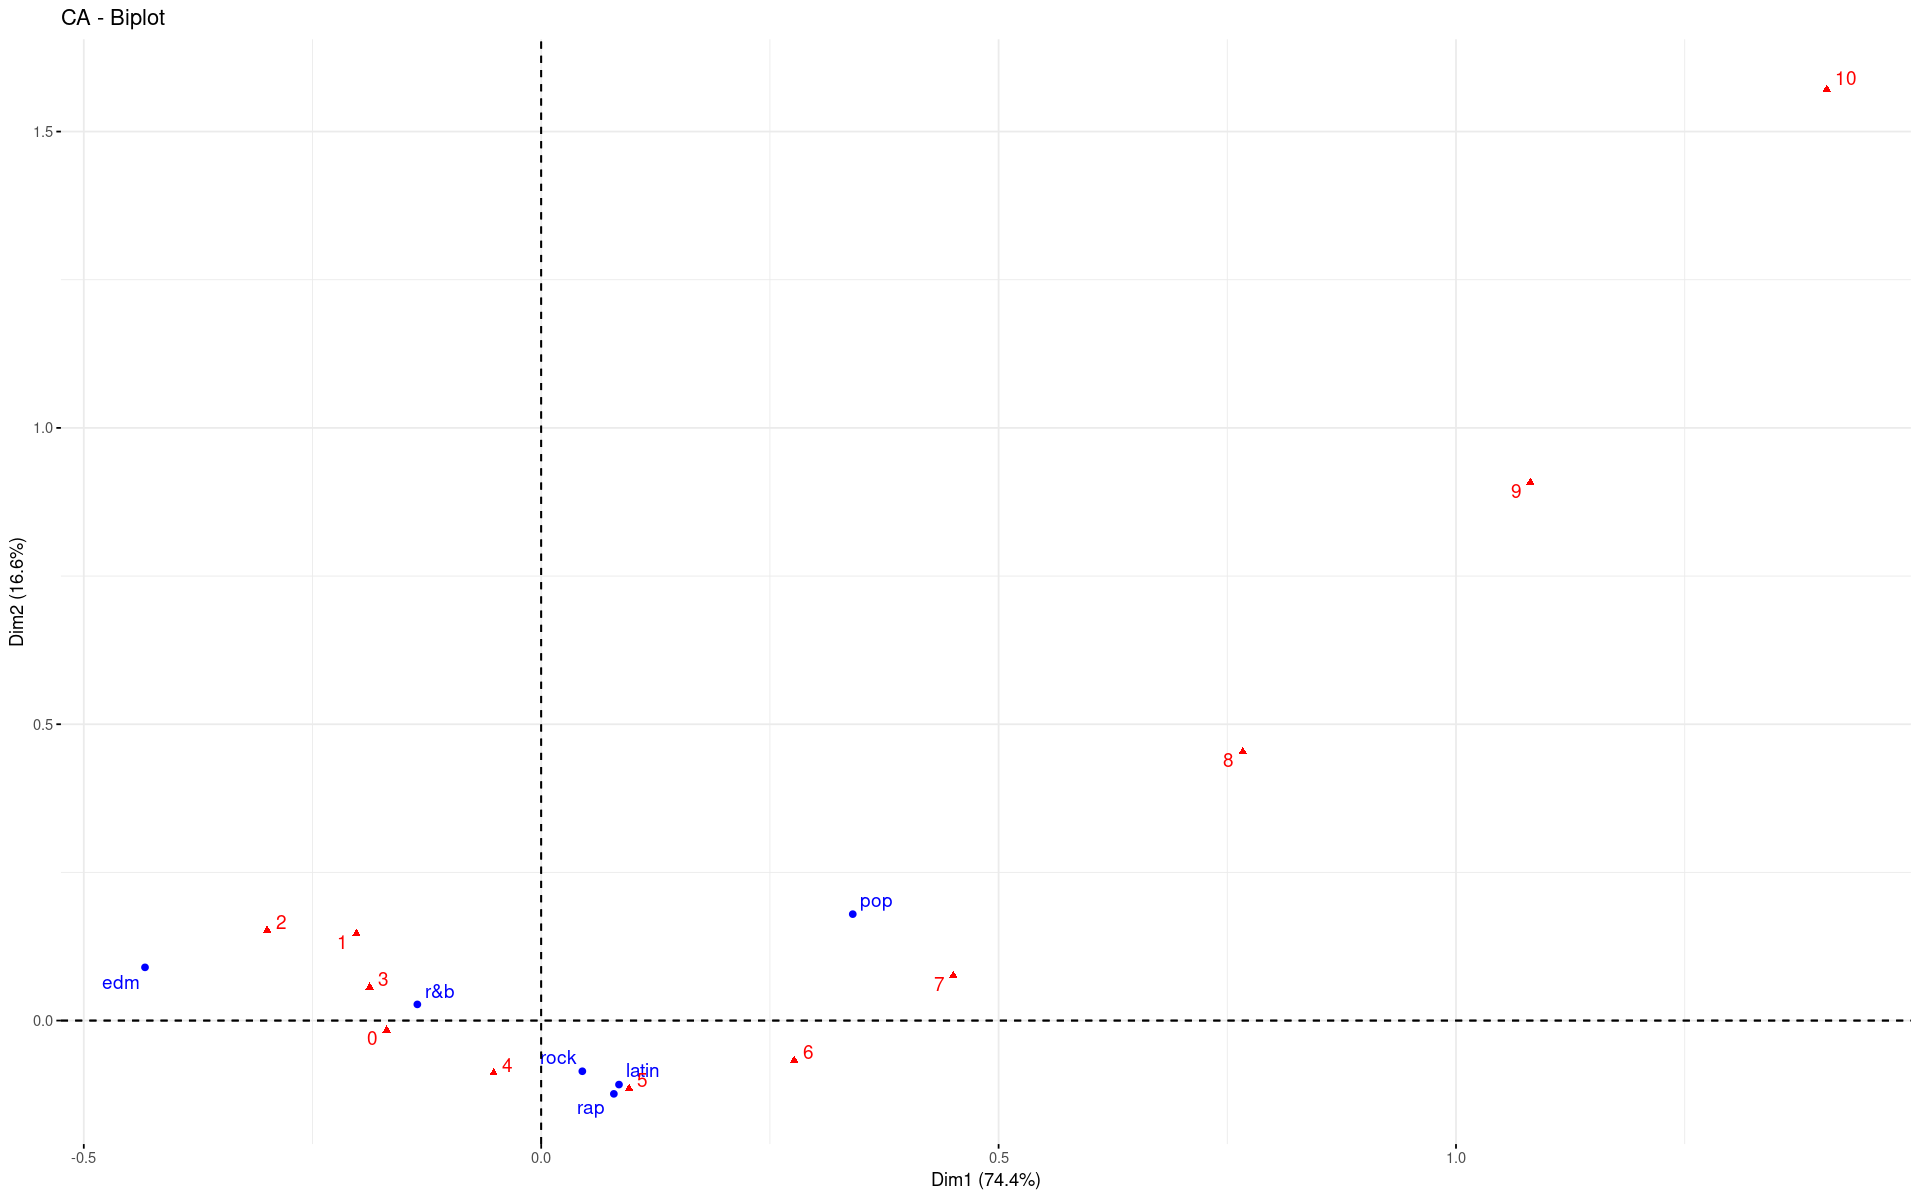

In [50]:
options(repr.plot.width=16,repr.plot.height=10)
fviz_ca_biplot(res.ca, repel=TRUE)

> On observe un lien entre les genre `edm`, `r&b` et les faibles popularités. On observe également un lien entre `rock`,`rap`,`latin` et les popularités moyennes. De mêmen `pop` a un lien avec les hautes popularité.
> On interprète cela comme le fait que le genre `pop` est un genre assez général, que tout le monde peut écouter assez souvent et aimer. Au contraire, les genres `edm` et `r&b` sont plus niches et ont une communauté plutôt restreinte. Les 3 derniers sont des genres avec des communautés plus importantes mais on ne peut pas forcément écouter ces musiques avec tout le monde et/ou dans toutes les situations.

## MCA

Pour étudier un impact potentiel du tempo dans certains intervalles, on va créer une variable `tempo_quali` de la même manière que la popularité dans la CA.

In [51]:
song <- song %>%
  mutate(
    tempo_quali = case_when(
      tempo < 40   ~ "Larghissimo",
      tempo < 60   ~ "Largo",
      tempo < 80   ~ "Adagio",
      tempo < 100  ~ "Andante",
      tempo < 120  ~ "Allegretto",
      tempo < 140  ~ "Vivace",
      tempo < 188  ~ "Presto",
      TRUE         ~ "Prestissimo"
    ),
    tempo_quali = as.factor(tempo_quali)
  )


In [52]:
song_quali<- song[c(5,9,11,19,21,22,23)]

In [53]:
head(song_quali)

,playlist_genre,key,mode,month,period,track_popularity_quali,tempo_quali
,<fct>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>
1,pop,6,1,06,2010s,6,Vivace
2,pop,11,1,12,2010s,6,Andante
3,pop,1,0,07,2010s,7,Vivace
4,pop,7,1,07,2010s,6,Vivace
5,pop,1,1,03,2010s,6,Vivace
6,pop,8,1,07,2010s,6,Vivace


In [54]:
res.mca = MCA(song_quali, graph=FALSE)


Warning message in sqrt(Nj * ((N - 1)/(N - Nj))):
“Production de NaN”


ERROR: Error in aggregate.data.frame(as.data.frame(x), ...): les arguments doivent avoir la même longueur


## Retrouver la décennie d'un titre en fonction de ses caractéristiques physiques : possible?

In [48]:
head(song)

,track_artist,track_popularity,track_album_name,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,⋯,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s,month,year,period
,<fct>,<int>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<int>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>
1,Ed Sheeran,66,I Don't Care (with Justin Bieber) [Loud Luxury Remix],Pop Remix,pop,dance pop,0.748,0.916,6,-2.634,⋯,0.0583,0.1020,0.00e+00,0.0653,0.518,122.036,194.754,06,2019,2010s
2,Maroon 5,67,Memories (Dillon Francis Remix),Pop Remix,pop,dance pop,0.726,0.815,11,-4.969,⋯,0.0373,0.0724,4.21e-03,0.3570,0.693,99.972,162.600,12,2019,2010s
3,Zara Larsson,70,All the Time (Don Diablo Remix),Pop Remix,pop,dance pop,0.675,0.931,1,-3.432,⋯,0.0742,0.0794,2.33e-05,0.1100,0.613,124.008,176.616,07,2019,2010s
4,The Chainsmokers,60,Call You Mine - The Remixes,Pop Remix,pop,dance pop,0.718,0.930,7,-3.778,⋯,0.1020,0.0287,9.43e-06,0.2040,0.277,121.956,169.093,07,2019,2010s
5,Lewis Capaldi,69,Someone You Loved (Future Humans Remix),Pop Remix,pop,dance pop,0.650,0.833,1,-4.672,⋯,0.0359,0.0803,0.00e+00,0.0833,0.725,123.976,189.052,03,2019,2010s
6,Ed Sheeran,67,Beautiful People (feat. Khalid) [Jack Wins Remix],Pop Remix,pop,dance pop,0.675,0.919,8,-5.385,⋯,0.1270,0.0799,0.00e+00,0.1430,0.585,124.982,163.049,07,2019,2010s


In [50]:
song_dec<-song[c(7:18,20,21)]


## Comprendre le lien entre popularité et composantes de la musique

In [ ]:
res.lm<-lm(track_popularity~.,data=song)

In [ ]:
summary(res.lm)

### Avec NMF

In [13]:
library(NMF)
library(scales)

Le chargement a nécessité le package : registry

Le chargement a nécessité le package : rngtools

Le chargement a nécessité le package : cluster

NMF - BioConductor layer [OK] | Shared memory capabilities [NO: bigmemory] | Cores 2/2

  To enable shared memory capabilities, try: install.extras('
NMF
')


Attachement du package : ‘NMF’


L'objet suivant est masqué depuis ‘package:generics’:

    fit




In [14]:
song_nmf<-subset(songLDA, select=-c(mode,playlist_genre,track_popularity)

In [15]:
song_nmf_scaled <-as.data.frame(lapply(song_nmf,rescale))
song_nmf_matrix<-as.matrix(song_nmf_scaled)

In [31]:
n_components=5
nmf_result<-nmf(song_nmf_matrix,rank=n_components,seed=42)
W<-basis(nmf_result)
H<-coef(nmf_result)

In [32]:
H

danceability,energy,key,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s
0.11517684,0.1196509045,1.212664e+00,0.17034766,4.241948e-03,1.398732e-06,2.220446e-16,9.840808e-04,0.038787419,0.09123578,0.09587773
0.51077702,0.4662846066,2.220446e-16,0.49460064,8.099127e-02,3.736664e-05,2.220446e-16,9.145994e-05,0.693289049,0.28164330,0.24160135
0.06320967,0.0587567346,2.220446e-16,0.05213002,2.220446e-16,6.510049e-05,3.267835e-01,1.473178e-07,0.003137092,0.04148564,0.04304994
0.35842164,0.5893317277,2.220446e-16,0.62497588,8.460813e-02,2.220446e-16,2.220446e-16,3.105899e-01,0.023423908,0.40151632,0.32861494
0.15962451,0.0003128338,2.220446e-16,0.18962987,3.909609e-02,4.488670e-01,2.220446e-16,5.455293e-02,0.055972804,0.12407625,0.10465103


Composante 1 : clé du morceau (plus ou moins aigu/grave)
Composante 2 : les musiques de la boom (entrainante,ce qui donne envie de faire la fête et de bouger)
Composante 3 : musique instrumentale
Composante 4 : les musiques forte ,qui pulsent, qui t'attaque (pas calme), musique de concert
Composante 5 : musique acoustique (vrai instrument, pas électronique)

In [33]:
W_df<-as.data.frame(W)
colnames(W_df)<-paste0("factor_",1:ncol(W_df))
W_df$popularity<-song$track_popularity
correlations<-cor(W_df)
print(correlations["popularity",])

    factor_1     factor_2     factor_3     factor_4     factor_5   popularity 
-0.007407942  0.035604928 -0.128054606 -0.086760634  0.095393243  1.000000000 


On observe une très légère corrélation négative entre la popularité et la 3ème composante latente qui correspond uniquement à l'instrumentalité. Ce résultat ne nous apporte pas beaucoup d'informations car avec la matrice de corrélations de base, on possédait déjà cette valeur de corrélation.

Si on veut faire une chanson qui a du succès, nos résultats suggèrent de faire une musique entraînante, avec beaucoup de parties vocales, assez calme (pas agressive), avec de vrais instruments; Néanmoins, les corrélations sont très faibles, il n'y a donc pas de recette magique pour produire une chanson à succès et on peut supposer que la popularité d'une chanson dépend davantage de l'artiste qui la sort que de ses propriétés physiques...

## MFA puis regression linéaire pour popularité

In [35]:
summary(song)

                    track_artist   track_popularity
 Queen                    :  130   Min.   :  0.00  
 Martin Garrix            :   87   1st Qu.: 21.00  
 Don Omar                 :   84   Median : 42.00  
 David Guetta             :   81   Mean   : 39.34  
 Dimitri Vegas & Like Mike:   68   3rd Qu.: 58.00  
 Drake                    :   68   Max.   :100.00  
 (Other)                  :27834                   
                    track_album_name            playlist_name   playlist_genre
 Greatest Hits              :  135   Indie Poptimism   :  294   edm  :4877    
 Ultimate Freestyle Mega Mix:   42   Permanent Wave    :  223   latin:4136    
 Gold                       :   34   Hard Rock Workout :  211   pop  :5132    
 Rock & Rios (Remastered)   :   29   Southern Hip Hop  :  174   r&b  :4504    
 Asian Dreamer              :   20   post teen pop     :  159   rap  :5398    
 Trip Stories               :   20   Urban Contemporary:  157   rock :4305    
 (Other)                    :28

In [14]:
song_mfa<-subset(song, select=-c(track_popularity, track_album_name, playlist_name, month, year))
song_mfa$key<-as.factor(song_mfa$key)

On choisit les groupes de façon suivante, sachant qu'ils doivent être homogènes:
- artiste
- genre et sous-genre
- caractéristiques physiques calculées par Spotify (danceability, speechiness, ...) dont les méthodes de calcul ne sont pas connues
- caractéristiques musicales (variables key et mode)
- tempo
- durée
- période

In [82]:
groupes <-list(
    genre = c("playlist_genre", "playlist_subgenre"),
    physique = c("danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence"),
    musique = c("key", "mode"),
    tempo = c("tempo"),
    durée = c("duration_s"),
    période = c("period"))
ordre_col <- unlist(groupes)
song_mfa_ord <- song_mfa[, ordre_col]
res.mfa <- MFA(song_mfa_ord, group = c( 2, 8, 2, 1, 1, 1), ncp=30,type = c("n", "s", "n", "s", "s", "n"), name.group = c("genre", "physique", "musique", "tempo", "durée", "période"),graph=FALSE)

In [83]:
data_mfa<-as.data.frame(res.mfa$ind$coord)
data_mfa$popularity<-song$track_popularity

In [84]:
head(data_mfa)

,Dim.1,Dim.2,Dim.3,Dim.4,Dim.5,Dim.6,Dim.7,Dim.8,Dim.9,Dim.10,⋯,Dim.22,Dim.23,Dim.24,Dim.25,Dim.26,Dim.27,Dim.28,Dim.29,Dim.30,popularity
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,-1.1288677,0.6324872,-0.2290573,0.4540096,-0.8623429,-1.387026,0.6083982,-0.4128724,-0.2559455,-0.6643792,⋯,0.1840729,0.5422923,-0.01411578,-0.04211668,-0.42843973,-0.28091074,0.5841707,-0.101292746,0.0886636,66
2,-1.0856727,0.2213211,-0.5533139,0.4723854,-0.9010753,-1.146689,0.6240807,-0.5088380,-0.2045937,-0.5381151,⋯,-0.0350284,0.1805593,-0.25686755,-0.01537039,-0.06198373,-0.16925234,0.7795015,-0.229526983,0.3366835,67
3,-1.4008821,0.4728488,-0.2026186,0.4977157,-0.5129201,-1.305363,0.8517669,-0.3328995,-0.3116146,-0.2845431,⋯,0.1572124,0.5237982,-0.82000174,-0.12660821,-0.92858296,0.63475844,-0.8233155,0.233150179,0.3879119,70
4,-1.1325104,0.8517973,-0.5864543,0.3647304,-0.5760742,-1.599886,0.3027493,-0.4871723,-0.4517112,-1.3382026,⋯,-0.2717816,1.3571180,0.68652598,-0.48322380,-0.47317766,0.45890622,-0.1004112,-0.007825788,0.1783655,60
5,-0.9671394,0.4930846,-0.5326847,0.5646729,-0.5884443,-1.754483,0.4812516,-0.3851687,-0.4218306,-0.9721024,⋯,0.2035682,0.4990380,-0.86196380,0.04355736,-0.69015532,0.03466773,-0.1291769,0.055193334,0.3499571,69
6,-1.2196244,0.5917597,-0.7451379,0.5450453,-0.4451828,-1.751356,0.6064054,-0.2631018,-0.3180313,-1.0569373,⋯,0.7641259,0.7076277,0.30115442,0.24870970,-0.43796721,0.31710155,0.1835743,0.266208305,0.3474493,67


In [85]:
sample<-sample(c(TRUE,FALSE),nrow(data_mfa),replace=TRUE,prob=c(0.7,0.3))
train<-data_mfa[sample,]
test<-data_mfa[!sample,]

In [86]:
lm.mfa<-lm(popularity~.,data=train)

In [87]:
summary(lm.mfa)


Call:
lm(formula = popularity ~ ., data = train)

Residuals:
   Min     1Q Median     3Q    Max 
-59.96 -16.78   2.73  17.44  56.72 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 39.42810    0.15936 247.420  < 2e-16 ***
Dim.1       -0.90817    0.11895  -7.635 2.36e-14 ***
Dim.2       -1.09703    0.12727  -8.620  < 2e-16 ***
Dim.3       -4.48439    0.14032 -31.958  < 2e-16 ***
Dim.4        1.64294    0.14696  11.180  < 2e-16 ***
Dim.5        0.50750    0.14773   3.435 0.000593 ***
Dim.6       -2.86999    0.15697 -18.283  < 2e-16 ***
Dim.7        0.30008    0.16154   1.858 0.063233 .  
Dim.8       -0.31463    0.17622  -1.785 0.074200 .  
Dim.9        0.87888    0.15985   5.498 3.88e-08 ***
Dim.10      -0.40802    0.16265  -2.509 0.012130 *  
Dim.11       2.52855    0.16352  15.463  < 2e-16 ***
Dim.12       1.38433    0.16717   8.281  < 2e-16 ***
Dim.13      -0.76223    0.17381  -4.385 1.16e-05 ***
Dim.14       0.61377    0.17718   3.464 0.000533 ***
Dim

In [88]:
pred.pop<-predict(lm.mfa,test)

In [89]:
sum(abs(pred.pop-test$popularity))/length(pred.pop)

[1] 18.76786